In [1]:
import re
import csv
import copy
import math
import json
import traceback
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
from scipy.optimize import root
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, SymLogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Circle, Patch
from scipy.sparse import csr_matrix, diags, eye
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from dataclasses import dataclass, replace, asdict, is_dataclass
from typing import Any, Dict, Iterable, Iterator, List, Mapping, Optional, Tuple

In [2]:
# ============================================================
# Parameters
# ============================================================

@dataclass(frozen=True)
class AreaParams:
    N: int
    s: float
    f_exc: float
    J_exc: float
    g_inh: float


@dataclass(frozen=True)
class MultiAreaParams:
    areas: Tuple[AreaParams, ...]
    s_cross: np.ndarray
    J_cross: np.ndarray
    allow_autapses: bool
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


# ============================================================
# Validation / bookkeeping
# ============================================================

def _validate_params(p: MultiAreaParams) -> None:
    A = len(p.areas)

    if p.s_cross.shape != (A, A):
        raise ValueError(f"s_cross must have shape ({A}, {A})")
    if p.J_cross.shape != (A, A):
        raise ValueError(f"J_cross must have shape ({A}, {A})")

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if not (0.0 <= ap.s <= 1.0):
            raise ValueError(f"Area {area_id}: s must be in [0, 1]")
        if not (0.0 <= ap.f_exc <= 1.0):
            raise ValueError(f"Area {area_id}: f_exc must be in [0, 1]")

    if np.any(p.s_cross < 0.0) or np.any(p.s_cross > 1.0):
        raise ValueError("All s_cross entries must be in [0, 1]")


def population_info(p: MultiAreaParams) -> Dict[str, Any]:
    """
    Build only the statistics needed by the theoretical formulas.
    """
    area_stats = []

    for area_id, ap in enumerate(p.areas):
        N_E = int(round(ap.f_exc * ap.N))
        N_I = ap.N - N_E

        C = int(round(ap.s * ap.N))
        C_E = int(round(ap.f_exc * C))
        C_I = C - C_E

        area_stats.append({
            "area_id": area_id,
            "N": ap.N,
            "N_E": N_E,
            "N_I": N_I,
            "C": C,
            "C_within": C,
            "C_E": C_E,
            "C_I": C_I,
            "J_E": ap.J_exc,
            "J_I": -ap.g_inh * ap.J_exc,
        })

    return {"area_stats": area_stats}


def add_connection_count_coordinates(records):
    """Add plotting coordinates that express sparsities as in-degree counts."""
    enriched = []
    for r in records:
        rr = dict(r)

        area_ids = sorted({
            int(k.split("]")[0][len("areas["):])
            for k in rr
            if k.startswith("areas[") and "]." in k
        })

        n_exc_by_area = {}
        for area_id in area_ids:
            try:
                N = int(round(float(rr[f"areas[{area_id}].N"])))
                s_within = float(rr[f"areas[{area_id}].s"])
                f_exc = float(rr[f"areas[{area_id}].f_exc"])
            except Exception:
                continue

            C_within = int(round(s_within * N))
            C_E = int(round(f_exc * C_within))
            C_I = C_within - C_E
            N_E = int(round(f_exc * N))

            rr[f"C_within[{area_id}]"] = C_within
            rr.setdefault(f"C_E[{area_id}]", C_E)
            rr.setdefault(f"C_I[{area_id}]", C_I)
            n_exc_by_area[area_id] = N_E

        for key, value in list(rr.items()):
            if not (key.startswith("s_cross[") and key.endswith("]")):
                continue
            try:
                src_s, tgt_s = key[len("s_cross["):-1].split(",")
                src = int(src_s)
                tgt = int(tgt_s)
                N_E_src = n_exc_by_area[src]
                s_cross = float(value)
            except Exception:
                continue
            rr.setdefault(f"C_cross[{src},{tgt}]", int(round(s_cross * N_E_src)))

        enriched.append(rr)
    return enriched


# ============================================================
# JSON helpers
# ============================================================

def to_jsonable(obj):
    """
    Convert object to JSON-safe form.
    Non-finite floats are stored as strings.
    """
    if is_dataclass(obj):
        return to_jsonable(asdict(obj))

    if isinstance(obj, np.ndarray):
        return to_jsonable(obj.tolist())

    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)

    if isinstance(obj, (np.floating, float)):
        x = float(obj)
        if np.isnan(x):
            return "__NAN__"
        if np.isposinf(x):
            return "__INF__"
        if np.isneginf(x):
            return "__-INF__"
        return x

    if isinstance(obj, (np.integer, int)):
        return int(obj)

    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}

    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]

    return obj


def _from_jsonable(obj):
    """
    Recover floats from the string placeholders.
    """
    if isinstance(obj, str):
        if obj == "__NAN__":
            return np.nan
        if obj == "__INF__":
            return np.inf
        if obj == "__-INF__":
            return -np.inf
        return obj

    if isinstance(obj, list):
        return [_from_jsonable(v) for v in obj]

    if isinstance(obj, dict):
        return {k: _from_jsonable(v) for k, v in obj.items()}

    return obj


def load_jsonl_records(path: str) -> List[Dict[str, Any]]:
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(_from_jsonable(json.loads(line)))
    return add_connection_count_coordinates(records)


# ============================================================
# Parameter flatten / update
# ============================================================

def flatten_params(p: MultiAreaParams) -> Dict[str, Any]:
    out: Dict[str, Any] = {}

    for i, ap in enumerate(p.areas):
        out[f"areas[{i}].N"] = int(ap.N)
        out[f"areas[{i}].s"] = float(ap.s)
        out[f"areas[{i}].f_exc"] = float(ap.f_exc)
        out[f"areas[{i}].J_exc"] = float(ap.J_exc)
        out[f"areas[{i}].g_inh"] = float(ap.g_inh)

    A = len(p.areas)
    for i in range(A):
        for j in range(A):
            out[f"s_cross[{i},{j}]"] = float(p.s_cross[i, j])
            out[f"J_cross[{i},{j}]"] = float(p.J_cross[i, j])

    out["allow_autapses"] = bool(p.allow_autapses)
    out["activation"] = p.activation
    out["phi_max"] = float(p.phi_max) if np.isfinite(p.phi_max) else np.inf
    out["gamma"] = float(p.gamma)
    out["dt"] = float(p.dt)
    out["T"] = float(p.T)
    out["seed"] = int(p.seed)

    return out


def apply_updates_to_params(base_p: MultiAreaParams, updates: Mapping[str, Any]) -> MultiAreaParams:
    """
    Apply updates like:
        "areas[0].s" -> 0.08
        "areas[1].J_exc" -> 0.04
        "s_cross[0,1]" -> 0.02
        "J_cross[1,0]" -> 0.05
        "gamma" -> 0.3

    Returns a NEW MultiAreaParams.
    """
    areas = list(base_p.areas)
    s_cross = np.array(base_p.s_cross, copy=True)
    J_cross = np.array(base_p.J_cross, copy=True)

    top_fields = {
        "allow_autapses": base_p.allow_autapses,
        "activation": base_p.activation,
        "phi_max": base_p.phi_max,
        "gamma": base_p.gamma,
        "dt": base_p.dt,
        "T": base_p.T,
        "seed": base_p.seed,
    }

    for key, value in updates.items():
        key = key.replace(" ", "")

        if key.startswith("areas["):
            left, field = key.split("].")
            area_idx = int(left[len("areas["):])
            old_area = areas[area_idx]
            areas[area_idx] = replace(old_area, **{field: value})

        elif key.startswith("s_cross["):
            inside = key[len("s_cross["):-1]
            i, j = map(int, inside.split(","))
            s_cross[i, j] = value

        elif key.startswith("J_cross["):
            inside = key[len("J_cross["):-1]
            i, j = map(int, inside.split(","))
            J_cross[i, j] = value

        elif key in top_fields:
            top_fields[key] = value

        else:
            raise KeyError(f"Unsupported parameter path: {key}")

    new_p = MultiAreaParams(
        areas=tuple(areas),
        s_cross=s_cross,
        J_cross=J_cross,
        allow_autapses=top_fields["allow_autapses"],
        activation=top_fields["activation"],
        phi_max=top_fields["phi_max"],
        gamma=top_fields["gamma"],
        dt=top_fields["dt"],
        T=top_fields["T"],
        seed=top_fields["seed"],
    )
    return new_p


# ============================================================
# Theory: random part R
# Full finite-sparsity formula, no sparse-limit reduction
# ============================================================

def _candidate_pool_size(
    pop_size: int,
    target_belongs_to_source_pool: bool,
    allow_autapses: bool
) -> int:
    """
    Exact source pool size under your construction rule.
    """
    if allow_autapses:
        return pop_size
    return pop_size - 1 if target_belongs_to_source_pool else pop_size


def _variance_fixed_indegree_entry(weight: float, indegree: int, pool_size: int) -> float:
    """
    Exact single-entry variance for fixed in-degree sampling without replacement:
        P(conn) = indegree / pool_size
        Var(W_ij) = weight^2 * p * (1-p)
    """
    if pool_size <= 0:
        return np.nan
    if indegree < 0 or indegree > pool_size:
        return np.nan

    p_conn = indegree / pool_size
    return (weight ** 2) * p_conn * (1.0 - p_conn)


def build_random_variance_matrix_full_4x4(p: MultiAreaParams) -> np.ndarray:
    """
    Full 4x4 block variance matrix G for the two-area case.

    Population order:
        0: area0,E
        1: area0,I
        2: area1,E
        3: area1,I

    G_cd = alpha_c * g_cd^2 = n_c * Var(block_cd entry)
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    N_E0, N_I0 = st0["N_E"], st0["N_I"]
    N_E1, N_I1 = st1["N_E"], st1["N_I"]

    C_E0, C_I0 = st0["C_E"], st0["C_I"]
    C_E1, C_I1 = st1["C_E"], st1["C_I"]

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * N_E0))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * N_E1))

    J0 = ap0.J_exc
    J1 = ap1.J_exc
    JI0 = -ap0.g_inh * ap0.J_exc
    JI1 = -ap1.g_inh * ap1.J_exc
    J_0_to_1 = float(p.J_cross[0, 1])
    J_1_to_0 = float(p.J_cross[1, 0])

    row_sizes = np.array([N_E0, N_I0, N_E1, N_I1], dtype=float)
    G = np.zeros((4, 4), dtype=float)

    # row 0: target area0, E
    G[0, 0] = row_sizes[0] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, True, p.allow_autapses)
    )
    G[0, 1] = row_sizes[0] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, False, p.allow_autapses)
    )
    G[0, 2] = row_sizes[0] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[0, 3] = 0.0

    # row 1: target area0, I
    G[1, 0] = row_sizes[1] * _variance_fixed_indegree_entry(
        J0, C_E0,
        _candidate_pool_size(N_E0, False, p.allow_autapses)
    )
    G[1, 1] = row_sizes[1] * _variance_fixed_indegree_entry(
        JI0, C_I0,
        _candidate_pool_size(N_I0, True, p.allow_autapses)
    )
    G[1, 2] = row_sizes[1] * _variance_fixed_indegree_entry(
        J_1_to_0, C_1_to_0, N_E1
    )
    G[1, 3] = 0.0

    # row 2: target area1, E
    G[2, 0] = row_sizes[2] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[2, 1] = 0.0
    G[2, 2] = row_sizes[2] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, True, p.allow_autapses)
    )
    G[2, 3] = row_sizes[2] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, False, p.allow_autapses)
    )

    # row 3: target area1, I
    G[3, 0] = row_sizes[3] * _variance_fixed_indegree_entry(
        J_0_to_1, C_0_to_1, N_E0
    )
    G[3, 1] = 0.0
    G[3, 2] = row_sizes[3] * _variance_fixed_indegree_entry(
        J1, C_E1,
        _candidate_pool_size(N_E1, False, p.allow_autapses)
    )
    G[3, 3] = row_sizes[3] * _variance_fixed_indegree_entry(
        JI1, C_I1,
        _candidate_pool_size(N_I1, True, p.allow_autapses)
    )

    return G


def theoretical_random_radius(p: MultiAreaParams) -> float:
    """
    Bulk radius of random part:
        r_R = sqrt( rho(G) )
    """
    G = build_random_variance_matrix_full_4x4(p)

    if not np.all(np.isfinite(G)):
        return np.nan

    eigvals = np.linalg.eigvals(G)
    rho = float(np.max(eigvals.real))

    if rho < 0.0 and abs(rho) < 1e-12:
        rho = 0.0
    if rho < 0.0:
        return np.nan

    return float(np.sqrt(rho))


# ============================================================
# Theory: structured part S
# Two meaningful real roots from reduced 2x2 matrix
# ============================================================

def build_structured_matrix_2x2(p: MultiAreaParams) -> np.ndarray:
    """
    Reduced 2x2 structured matrix:

        [ Lambda_0      Gamma_{1->0} ]
        [ Gamma_{0->1}  Lambda_1     ]

    where
        Lambda_i = J_i * (C_Ei - g_i C_Ii)
        Gamma_{src->tgt} = J_cross[src,tgt] * C_{src->tgt}
    """
    _validate_params(p)

    if len(p.areas) != 2:
        raise ValueError("Current implementation assumes exactly 2 areas.")

    info = population_info(p)
    st0, st1 = info["area_stats"]
    ap0, ap1 = p.areas

    C_0_to_1 = int(round(float(p.s_cross[0, 1]) * st0["N_E"]))
    C_1_to_0 = int(round(float(p.s_cross[1, 0]) * st1["N_E"]))

    Lambda_0 = ap0.J_exc * (st0["C_E"] - ap0.g_inh * st0["C_I"])
    Lambda_1 = ap1.J_exc * (st1["C_E"] - ap1.g_inh * st1["C_I"])

    Gamma_0_to_1 = float(p.J_cross[0, 1]) * C_0_to_1
    Gamma_1_to_0 = float(p.J_cross[1, 0]) * C_1_to_0

    return np.array([
        [Lambda_0,     Gamma_1_to_0],
        [Gamma_0_to_1, Lambda_1    ],
    ], dtype=float)


def theoretical_structured_roots(p: MultiAreaParams) -> Tuple[float, float]:
    """
    Return the two nonzero real eigenvalues of S:
        lambda_plus >= lambda_minus
    """
    M = build_structured_matrix_2x2(p)
    eigvals = np.linalg.eigvals(M)

    if np.max(np.abs(eigvals.imag)) > 1e-10:
        return np.nan, np.nan

    vals = np.sort(eigvals.real)[::-1]
    return float(vals[0]), float(vals[1])


# ============================================================
# Theory: exact 2D fixed point in the stable linear regime
# ============================================================

def _nan_fixed_point_diagnostics(
    *,
    success: int = 0,
    stable: Any = np.nan,
    linear_valid: int = 0,
    reason: str = "not_computed",
) -> Dict[str, Any]:
    """
    Standard nan-valued fixed-point payload used for singular or invalid cases.
    """
    return {
        "fixed_point_theory_success": int(success),
        "fixed_point_theory_stable": stable,
        "fixed_point_theory_linear_valid": int(linear_valid),
        "fixed_point_theory_reason": reason,
        "x_star_area0": np.nan,
        "x_star_area1": np.nan,
        "rate_area0": np.nan,
        "rate_area1": np.nan,
        "x_star_mean": np.nan,
        "x_star_max": np.nan,
        "x_star_min": np.nan,
        "x_star_area_diff_0_minus_1": np.nan,
        "x_star_area0_minus_global": np.nan,
        "x_star_area1_minus_global": np.nan,
    }


def _is_threshold_linear_unbounded(p: MultiAreaParams) -> bool:
    return p.activation == "threshold_linear" and bool(np.isinf(p.phi_max))


def theoretical_fixed_point_2area(
    p: MultiAreaParams,
    stable_only: bool = False,
    W_lambda_max: Optional[float] = None,
    singular_tol: float = 1e-12,
    linear_tol: float = 1e-10,
) -> Dict[str, Any]:
    """
    Exact area-uniform fixed point from Different_activities_between_areas.pdf.

    In the threshold-linear unbounded regime, the area means satisfy
        (I - M_structure) x_star = gamma * M_structure @ [1, 1].

    The algebraic solution is computed whenever I - M_structure is invertible.
    Stability and linear-regime validity are reported separately, so unstable
    algebraic continuations can be inspected but masked in plotting helpers.
    """
    M = build_structured_matrix_2x2(p)
    A = np.eye(2, dtype=float) - M
    det_A = float(np.linalg.det(A))

    if not np.isfinite(det_A) or abs(det_A) < singular_tol:
        return _nan_fixed_point_diagnostics(reason="singular_I_minus_M")

    try:
        rhs = float(p.gamma) * (M @ np.ones(2, dtype=float))
        x_star = np.linalg.solve(A, rhs)
    except Exception:
        return _nan_fixed_point_diagnostics(reason="solve_failed")

    if not np.all(np.isfinite(x_star)):
        return _nan_fixed_point_diagnostics(reason="nonfinite_solution")

    if W_lambda_max is None:
        R_radius = theoretical_random_radius(p)
        S_plus, _ = theoretical_structured_roots(p)
        W_lambda_max = float(max(R_radius, S_plus)) if np.isfinite(R_radius) and np.isfinite(S_plus) else np.nan

    stable = bool(np.isfinite(W_lambda_max) and W_lambda_max < 1.0)
    linear_valid = bool(
        _is_threshold_linear_unbounded(p)
        and np.all(x_star >= (-float(p.gamma) - linear_tol))
    )

    if stable_only and not stable:
        return _nan_fixed_point_diagnostics(
            success=1,
            stable=int(stable),
            linear_valid=int(linear_valid),
            reason="unstable_masked_by_stable_only",
        )

    if not linear_valid:
        return _nan_fixed_point_diagnostics(
            success=1,
            stable=int(stable),
            linear_valid=0,
            reason="outside_threshold_linear_regime",
        )

    rates = x_star + float(p.gamma)
    x_mean = float(np.mean(x_star))

    return {
        "fixed_point_theory_success": 1,
        "fixed_point_theory_stable": int(stable),
        "fixed_point_theory_linear_valid": 1,
        "fixed_point_theory_reason": "ok" if stable else "unstable_algebraic_continuation",
        "x_star_area0": float(x_star[0]),
        "x_star_area1": float(x_star[1]),
        "rate_area0": float(rates[0]),
        "rate_area1": float(rates[1]),
        "x_star_mean": x_mean,
        "x_star_max": float(np.max(x_star)),
        "x_star_min": float(np.min(x_star)),
        "x_star_area_diff_0_minus_1": float(x_star[0] - x_star[1]),
        "x_star_area0_minus_global": float(x_star[0] - x_mean),
        "x_star_area1_minus_global": float(x_star[1] - x_mean),
    }


# ============================================================
# Diagnostics at one scan point
# ============================================================

def compute_theoretical_diagnostics(
    p: MultiAreaParams,
    compute_fixed_point: bool = True,
    fixed_point_stable_only: bool = False,
) -> Dict[str, Any]:
    """
    All theory-only quantities for one parameter point.
    """
    info = population_info(p)
    st0, st1 = info["area_stats"]

    R_radius = theoretical_random_radius(p)
    S_plus, S_minus = theoretical_structured_roots(p)

    # Combined-spectrum stability prediction for W = R + S.
    # Under Tao's bounded-rank perturbation theorem (eq.(68) in the notes),
    # the spectrum of W is the bulk disk of radius R_radius plus the
    # outliers at the eigenvalues of S. The rightmost real eigenvalue of W
    # controls the transition to chaos, so we use
    #     lambda_max(W) = max(R_radius, S_lambda_plus).
    if np.isfinite(R_radius) and np.isfinite(S_plus):
        W_lambda_max = float(max(R_radius, S_plus))
    else:
        W_lambda_max = np.nan

    out = {
        "R_radius": R_radius,
        "R_radius_minus_1": R_radius - 1.0,
        "S_lambda_plus": S_plus,
        "S_lambda_minus": S_minus,
        "S_lambda_plus_minus_1": S_plus - 1.0,
        "S_lambda_minus_minus_1": S_minus - 1.0,
        "W_lambda_max": W_lambda_max,
        "W_lambda_max_minus_1": W_lambda_max - 1.0,
        "C_within[0]": st0["C_within"],
        "C_within[1]": st1["C_within"],
        "C_cross[0,1]": int(round(float(p.s_cross[0, 1]) * st0["N_E"])),
        "C_cross[1,0]": int(round(float(p.s_cross[1, 0]) * st1["N_E"])),
        "C_E[0]": st0["C_E"],
        "C_I[0]": st0["C_I"],
        "C_E[1]": st1["C_E"],
        "C_I[1]": st1["C_I"],
    }

    if compute_fixed_point:
        out.update(theoretical_fixed_point_2area(
            p,
            stable_only=fixed_point_stable_only,
            W_lambda_max=W_lambda_max,
        ))

    return out


# ============================================================
# Scan interface: keep the same style as your old code
# ============================================================

def run_parameter_scan(
    base_p: MultiAreaParams,
    scan_points: Iterable[Mapping[str, Any]],
    output_file: Optional[str] = None,
    solve_fixed_point: bool = False,
    flush_every: int = 1,
) -> List[Dict[str, Any]]:
    """
    Same external interface style as your original version.

    This version is theory only. Fixed-point diagnostics are computed by
    default because the exact 2D solve is cheap; solve_fixed_point is kept
    for compatibility and can be set True by older call sites without
    changing behavior.

    Returns:
        list of records
    """
    compute_fixed_point = True

    records: List[Dict[str, Any]] = []

    fout = None
    if output_file is not None:
        fout = open(output_file, "w", encoding="utf-8")

    try:
        for idx, updates in enumerate(scan_points):
            rec: Dict[str, Any] = {
                "scan_index": idx,
                "updates": dict(updates),
            }

            try:
                p_now = apply_updates_to_params(base_p, updates)
                rec.update(flatten_params(p_now))
                rec.update(compute_theoretical_diagnostics(
                    p_now,
                    compute_fixed_point=compute_fixed_point,
                    fixed_point_stable_only=False,
                ))
                rec["success"] = 1

            except Exception as e:
                rec["success"] = 0
                rec["error"] = str(e)

            records.append(rec)

            if fout is not None:
                fout.write(json.dumps(to_jsonable(rec), ensure_ascii=False) + "\n")
                if flush_every > 0 and ((idx + 1) % flush_every == 0):
                    fout.flush()

    finally:
        if fout is not None:
            fout.close()

    return records


# ============================================================
# Generic grid builder from scan records
# ============================================================

def _canonical_float(x: Any, ndigits: int = 12) -> float:
    return round(float(x), ndigits)


def records_to_grid(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    z_key: str,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert scan records into a 2D grid for heatmap plotting.

    Returns:
        x_values, y_values, Z
    """
    valid = []
    for r in records:
        if r.get("success", 0) != 1:
            continue
        if x_key not in r or y_key not in r or z_key not in r:
            continue
        valid.append(r)

    if len(valid) == 0:
        raise ValueError("No valid records found for the requested keys.")

    x_vals = sorted({_canonical_float(r[x_key]) for r in valid})
    y_vals = sorted({_canonical_float(r[y_key]) for r in valid})

    x_index = {v: i for i, v in enumerate(x_vals)}
    y_index = {v: i for i, v in enumerate(y_vals)}

    Z = np.full((len(y_vals), len(x_vals)), np.nan, dtype=float)

    for r in valid:
        x = _canonical_float(r[x_key])
        y = _canonical_float(r[y_key])

        try:
            z = float(r[z_key])
        except Exception:
            z = np.nan

        Z[y_index[y], x_index[x]] = z

    return np.asarray(x_vals), np.asarray(y_vals), Z


# ============================================================
# Generic heatmap plotter
# ============================================================

def _cutoff_diverging_cmap(cmap_obj, cutoff: float, vmin: float, vmax: float, n: int = 256):
    """
    Remap a diverging colormap so the blue/red transition occurs at a
    data-space cutoff while the colorbar axis remains linearly scaled.
    """
    if not (np.isfinite(vmin) and np.isfinite(vmax) and vmin < cutoff < vmax):
        return cmap_obj

    cutoff_pos = (float(cutoff) - float(vmin)) / (float(vmax) - float(vmin))
    positions = np.unique(np.concatenate([np.linspace(0.0, 1.0, n), [cutoff_pos]]))
    sample_positions = np.empty_like(positions)

    below = positions <= cutoff_pos
    sample_positions[below] = 0.5 * positions[below] / cutoff_pos
    sample_positions[~below] = 0.5 + 0.5 * (positions[~below] - cutoff_pos) / (1.0 - cutoff_pos)

    colors = cmap_obj(sample_positions)
    return LinearSegmentedColormap.from_list(
        f"{cmap_obj.name}_cutoff_{cutoff:g}",
        list(zip(positions, colors)),
        N=len(positions),
    )


def plot_metric_heatmap(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    z_key: str,
    title: Optional[str] = None,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    cbar_label: Optional[str] = None,
    contour_level: Optional[float] = 1.0,
    ax: Optional[plt.Axes] = None,
    cmap: str = "viridis",
    invalid_color: str = "0.5",
    center: Optional[float] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    value_scale: str = "linear",
    linthresh: Optional[float] = None,
    color_cutoff: Optional[float] = None,
    clip: bool = True,
) -> plt.Axes:
    """
    Plot one metric heatmap from scan records.

    Parameters
    ----------
    value_scale : {"linear", "symlog"}
        "linear" uses TwoSlopeNorm when center is given, else a plain
        linear mapping. "symlog" uses SymLogNorm with the given linthresh
        (defaults to max(|vmin|, |vmax|)/100), keeping small values linear
        and compressing large values logarithmically.
    color_cutoff : float, optional
        Data-space value where a diverging colormap switches from its lower
        half to upper half while keeping a linear colorbar axis. For example,
        color_cutoff=0 maps values below 0 to blue and above 0 to red even
        when vmin and vmax are asymmetric. Ignored when center creates a
        TwoSlopeNorm or when value_scale="symlog".
    clip : bool
        If True (default), values outside [vmin, vmax] are rendered as
        the colormap's over/under saturation colors instead of expanding
        the auto-scale. Lets a moderate vmax preserve low-value structure
        while still indicating direction of out-of-range cells.
    """
    x_values, y_values, Z = records_to_grid(records, x_key, y_key, z_key)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    cmap_obj = plt.get_cmap(cmap).copy()

    Zm = np.ma.masked_invalid(Z)
    X, Y = np.meshgrid(x_values, y_values)

    norm = None
    if value_scale == "symlog":
        finite_vals = Z[np.isfinite(Z)]
        if finite_vals.size > 0:
            if vmin is None or vmax is None:
                scale_center = center if center is not None else 0.0
                scale = float(np.nanmax(np.abs(finite_vals - scale_center)))
                if scale == 0.0:
                    scale = 1.0
                if vmin is None:
                    vmin = scale_center - scale
                if vmax is None:
                    vmax = scale_center + scale
            lt = linthresh
            if lt is None:
                lt = max(abs(vmax), abs(vmin)) / 100.0
                if lt <= 0.0:
                    lt = 1.0
            norm = SymLogNorm(linthresh=lt, vmin=vmin, vmax=vmax, base=10)
    elif center is not None:
        finite_vals = Z[np.isfinite(Z)]
        if finite_vals.size > 0:
            if vmin is None or vmax is None:
                scale = float(np.nanmax(np.abs(finite_vals - center)))
                if scale == 0.0:
                    scale = 1.0
                if vmin is None:
                    vmin = center - scale
                if vmax is None:
                    vmax = center + scale
            if vmin < center < vmax:
                norm = TwoSlopeNorm(vmin=vmin, vcenter=center, vmax=vmax)

    elif color_cutoff is not None:
        finite_vals = Z[np.isfinite(Z)]
        if finite_vals.size > 0:
            if vmin is None:
                vmin = float(np.nanmin(finite_vals))
            if vmax is None:
                vmax = float(np.nanmax(finite_vals))
            if vmin < color_cutoff < vmax:
                norm = Normalize(vmin=vmin, vmax=vmax)

    if value_scale == "linear" and color_cutoff is not None and type(norm) is Normalize:
        if vmin is not None and vmax is not None:
            cmap_obj = _cutoff_diverging_cmap(cmap_obj, color_cutoff, vmin, vmax)

    cmap_obj = cmap_obj.copy()
    cmap_obj.set_bad(color=invalid_color)
    if clip:
        cmap_obj.set_over(cmap_obj(1.0))
        cmap_obj.set_under(cmap_obj(0.0))

    extend = "neither"
    if clip and np.any(np.isfinite(Z)):
        finite_vals = Z[np.isfinite(Z)]
        over = vmax is not None and np.any(finite_vals > vmax)
        under = vmin is not None and np.any(finite_vals < vmin)
        if over and under:
            extend = "both"
        elif over:
            extend = "max"
        elif under:
            extend = "min"

    im = ax.pcolormesh(
        X,
        Y,
        Zm,
        shading="nearest",
        cmap=cmap_obj,
        norm=norm,
        vmin=None if norm else vmin,
        vmax=None if norm else vmax,
    )
    cbar = plt.colorbar(im, ax=ax, extend=extend)
    cbar.set_label(cbar_label if cbar_label is not None else z_key, fontsize=16)
    cbar.ax.tick_params(labelsize=13)

    if contour_level is not None and np.any(np.isfinite(Z)):
        zmin = np.nanmin(Z)
        zmax = np.nanmax(Z)
        if zmin <= contour_level <= zmax:
            ax.contour(
                X, Y, Z,
                levels=[contour_level],
                colors="red",
                linewidths=2.0,
            )

    ax.set_title(title if title is not None else z_key,  fontsize=18)
    ax.set_xlabel(xlabel if xlabel is not None else x_key,  fontsize=18)
    ax.set_ylabel(ylabel if ylabel is not None else y_key,  fontsize=18)

    if np.any(~np.isfinite(Z)):
        ax.legend(
            handles=[Patch(facecolor=invalid_color, edgecolor="k", label="inf")],
            loc="upper right",
            framealpha=0.85,
        )

    return ax


def plot_theory_triptych(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    figsize: Tuple[float, float] = (24, 5),
) -> Tuple[plt.Figure, np.ndarray]:
    """
    Plot the 4 theory panels:
        1) R bulk radius
        2) S largest real root
        3) S second real root
        4) Combined-spectrum stability boundary of W = R + S,
           lambda_max(W) = max(R_radius, S_lambda_plus)
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        records=records,
        x_key=x_key,
        y_key=y_key,
        z_key="R_radius",
        title="Random part radius",
        xlabel=xlabel,
        ylabel=ylabel,
        cbar_label=r"$r_R = \sqrt{\rho(G)}$",
        contour_level=1.0,
        ax=axes[0],
    )

    plot_metric_heatmap(
        records=records,
        x_key=x_key,
        y_key=y_key,
        z_key="S_lambda_plus",
        title="Structural part largest real root",
        xlabel=xlabel,
        ylabel=ylabel,
        cbar_label=r"$\lambda_{+}(S)$",
        contour_level=1.0,
        ax=axes[1],
    )

    plot_metric_heatmap(
        records=records,
        x_key=x_key,
        y_key=y_key,
        z_key="S_lambda_minus",
        title="Structural part second real root",
        xlabel=xlabel,
        ylabel=ylabel,
        cbar_label=r"$\lambda_{-}(S)$",
        contour_level=1.0,
        ax=axes[2],
    )

    plot_metric_heatmap(
        records=records,
        x_key=x_key,
        y_key=y_key,
        z_key="W_lambda_max",
        title="Combined spectrum stability boundary",
        xlabel=xlabel,
        ylabel=ylabel,
        cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
        contour_level=1.0,
        ax=axes[3],
    )

    return fig, axes


# ============================================================
# Fixed-point plotting helpers
# ============================================================

_FIXED_POINT_METRIC_KEYS = (
    "x_star_area0",
    "x_star_area1",
    "rate_area0",
    "rate_area1",
    "x_star_mean",
    "x_star_max",
    "x_star_min",
    "x_star_area_diff_0_minus_1",
    "x_star_area0_minus_global",
    "x_star_area1_minus_global",
)


def mask_fixed_point_records(
    records: List[Dict[str, Any]],
    require_stable: bool = True,
    require_linear_valid: bool = True,
) -> List[Dict[str, Any]]:
    """
    Return shallow record copies with fixed-point metrics masked to nan unless
    they satisfy the plotting validity requirements.
    """
    masked = []
    for r in records:
        rr = dict(r)
        ok = rr.get("success", 0) == 1 and rr.get("fixed_point_theory_success", 0) == 1
        if require_stable:
            ok = ok and rr.get("fixed_point_theory_stable", 0) == 1
        if require_linear_valid:
            ok = ok and rr.get("fixed_point_theory_linear_valid", 0) == 1

        if not ok:
            for key in _FIXED_POINT_METRIC_KEYS:
                if key in rr:
                    rr[key] = np.nan
        masked.append(rr)
    return masked


def _records_gamma(records: List[Dict[str, Any]]) -> float:
    """
    Best-effort gamma extracted from scan records (every record carries it
    via flatten_params). Falls back to 1.0 if absent.
    """
    for r in records:
        g = r.get("gamma", None)
        if g is not None and np.isfinite(float(g)):
            return float(g)
    return 1.0


def _theory_cap(gamma: float, W_target: float) -> float:
    """
    Moderate theory-derived upper bound for |x*|. Fixed-point magnitude
    grows like gamma * W / (1 - W) where W = W_lambda_max is the combined-
    spectrum stability quantity. Choosing W_target one safety margin below
    criticality gives a moderate cap that preserves the well-behaved region
    while clipping the |x*| -> infinity blowup near W -> 1.
    """
    W_target = float(W_target)
    if not (0.0 < W_target < 1.0):
        raise ValueError("W_target must be in (0, 1)")
    return float(gamma) * W_target / (1.0 - W_target)


def plot_fixed_point_theory_panels(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    figsize: Tuple[float, float] = (18, 5),
    require_stable: bool = True,
    require_linear_valid: bool = True,
    W_target: float = 0.97,
    value_scale: str = "linear",
) -> Tuple[plt.Figure, np.ndarray]:
    """
    Plot fixed-point area currents and area difference.
    By default, only stable threshold-linear-valid fixed points are shown.

    Colorbar bounds are theory-derived (no per-scan tuning):
        vmax = gamma * W_target / (1 - W_target)
        vmin = -gamma     (matches threshold-linear lower edge)

    With W_target=0.9 and gamma=0.5 this gives vmax = 4.5, keeping low-
    value structure visible while clipping the |x*| -> infinity blowup
    near criticality. Fixed-point panels use color_cutoff=0 so blue means
    x* < 0 and red means x* > 0 without forcing symmetric colorbar spans.
    Pass value_scale="symlog" for scans whose stable region legitimately
    spans many orders of magnitude.
    """
    plot_records = mask_fixed_point_records(
        records,
        require_stable=require_stable,
        require_linear_valid=require_linear_valid,
    )
    gamma = _records_gamma(records)
    vmax = _theory_cap(gamma, W_target)
    vmin = -float(gamma)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area0",
        title="Fixed point area 0",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_0 \rangle$",
        contour_level=None,
        ax=axes[0],
        cmap="coolwarm",
        color_cutoff=0.0,
        vmin=vmin, vmax=vmax, value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area1",
        title="Fixed point area 1",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_1 \rangle$",
        contour_level=None,
        ax=axes[1],
        cmap="coolwarm",
        color_cutoff=0.0,
        vmin=vmin, vmax=vmax, value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_mean",
        title="Mean fixed point",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^* \rangle$",
        contour_level=None,
        ax=axes[2],
        cmap="coolwarm",
        color_cutoff=0.0,
        vmin=vmin, vmax=vmax, value_scale=value_scale, clip=True,
    )
    '''
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area_diff_0_minus_1",
        title="Area fixed-point difference",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$x^*_0 - x^*_1$",
        contour_level=0.0,
        ax=axes[3],
        cmap="coolwarm",
        color_cutoff=0.0,
    )
    '''
    
    return fig, axes


def plot_fixed_point_difference_panels(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    figsize: Tuple[float, float] = (18, 5),
    require_stable: bool = True,
    require_linear_valid: bool = True,
    W_target: float = 0.9,
    value_scale: str = "linear",
) -> Tuple[plt.Figure, np.ndarray]:
    """
    Plot area-minus-global and area-difference fixed-point diagnostics.

    Difference colorbars switch from blue to red at 0. The symmetric cap
    is theory-derived: cap = gamma * W_target / (1 - W_target). Halved on
    minus-global panels because |x_k - x_mean| <= |x_0 - x_1| / 2.
    """
    plot_records = mask_fixed_point_records(
        records,
        require_stable=require_stable,
        require_linear_valid=require_linear_valid,
    )
    gamma = _records_gamma(records)
    cap = _theory_cap(gamma, W_target)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area0_minus_global",
        title="Area 0 minus global mean",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_0 \rangle - \langle x^* \rangle$",
        contour_level=None,
        ax=axes[0],
        cmap="coolwarm",
        color_cutoff=0.0,
        vmin=-cap / 2.0, vmax=cap / 2.0,
        value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area1_minus_global",
        title="Area 1 minus global mean",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_1 \rangle - \langle x^* \rangle$",
        contour_level=None,
        ax=axes[1],
        cmap="coolwarm",
        color_cutoff=0.0,
        vmin=-cap / 2.0, vmax=cap / 2.0,
        value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area_diff_0_minus_1",
        title="Area fixed-point difference",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_0 \rangle - \langle x^*_1 \rangle$",
        contour_level=None,
        ax=axes[2],
        cmap="coolwarm",
        color_cutoff=0.0,
        vmin=-cap, vmax=cap,
        value_scale=value_scale, clip=True,
    )

    return fig, axes


def plot_fixed_point_slice_line(
    records: List[Dict[str, Any]],
    fixed_key: str,
    fixed_value: float,
    varying_key: str,
    z_key: str = "x_star_area_diff_0_minus_1",
    tol: float = 1e-8,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (6, 4),
    require_stable: bool = True,
    require_linear_valid: bool = True,
    ax: Optional[plt.Axes] = None,
) -> Tuple[plt.Figure, plt.Axes, pd.DataFrame]:
    """
    Plot a one-dimensional fixed-point slice, useful for checking pinned
    critical-condition values.
    """
    plot_records = mask_fixed_point_records(
        records,
        require_stable=require_stable,
        require_linear_valid=require_linear_valid,
    )

    rows = []
    for r in plot_records:
        if r.get("success", 0) != 1 or fixed_key not in r or varying_key not in r or z_key not in r:
            continue
        fixed = float(r[fixed_key])
        if abs(fixed - fixed_value) > tol:
            continue
        rows.append({
            varying_key: float(r[varying_key]),
            z_key: float(r[z_key]) if np.isfinite(float(r[z_key])) else np.nan,
        })

    if len(rows) == 0:
        raise ValueError(f"No rows found for {fixed_key} near {fixed_value}")

    df = pd.DataFrame(rows).sort_values(varying_key)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    finite = np.isfinite(df[z_key].to_numpy(dtype=float))
    ax.plot(
        df.loc[finite, varying_key],
        df.loc[finite, z_key],
        marker="o",
        linestyle="-",
    )
    if np.any(~finite):
        ax.scatter(df.loc[~finite, varying_key], np.zeros(np.sum(~finite)), marker="x", label="masked")
        ax.legend()

    ax.set_xlabel(xlabel if xlabel is not None else varying_key)
    ax.set_ylabel(ylabel if ylabel is not None else z_key)
    ax.set_title(title if title is not None else f"{z_key} at {fixed_key}={fixed_value}")
    

    return fig, ax, df


In [3]:
# ============================================================
# Visual helpers added in 2026-05 pass:
#   - shared spectra colorbar range
#   - combined-spectrum stability boundary contour overlay
#   - re-defined plot_theory_triptych, plot_fixed_point_theory_panels,
#     plot_fixed_point_difference_panels using the helpers above.
#
# This cell is intentionally placed AFTER the original helpers cell
# so the redefined functions take precedence (last def wins in Python).
# ============================================================


def _shared_value_range(records, z_keys, *, percentile=None, cap=None):
    """One (vmin, vmax) covering finite values of all z_keys over records.

    If percentile is given (e.g. 99) uses the (100-p, p) percentile pair
    instead of strict min/max so a single divergence near criticality
    doesn't crush the rest of the dynamic range.
    `cap` is an optional hard upper bound on vmax (e.g. cap=2.0).
    """
    vals = []
    for r in records:
        if r.get("success", 0) != 1:
            continue
        for k in z_keys:
            v = r.get(k, np.nan)
            try:
                fv = float(v)
            except Exception:
                continue
            if np.isfinite(fv):
                vals.append(fv)
    if not vals:
        return None, None
    arr = np.asarray(vals, dtype=float)
    if percentile is not None:
        lo, hi = np.percentile(arr, [100.0 - percentile, percentile])
    else:
        lo, hi = float(arr.min()), float(arr.max())
    if cap is not None:
        hi = min(float(hi), float(cap))
    return float(lo), float(hi)


def overlay_stability_boundary(
    ax, records, x_key, y_key,
    *,
    level=1.0,
    color="black",
    linewidth=2.0,
    linestyle="--",
    boundary_key="W_lambda_max",
):
    """Overlay W_lambda_max == level on an existing axis.

    Records source is whatever the caller passed — this notebook is the
    theory notebook, so the level set is the *theoretical* combined-spectrum
    boundary. Returns the contour set, or None if the level isn't crossed.
    """
    try:
        x_vals, y_vals, Z = records_to_grid(records, x_key, y_key, boundary_key)
    except ValueError:
        return None
    if not np.any(np.isfinite(Z)):
        return None
    zmin = float(np.nanmin(Z))
    zmax = float(np.nanmax(Z))
    if not (zmin <= level <= zmax):
        return None
    X, Y = np.meshgrid(x_vals, y_vals)
    return ax.contour(
        X, Y, Z,
        levels=[level],
        colors=color,
        linewidths=linewidth,
        linestyles=linestyle,
    )


def plot_theory_triptych(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    figsize: Tuple[float, float] = (24, 5),
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    percentile: float = 99,
    cap: Optional[float] = None,
) -> Tuple[plt.Figure, np.ndarray]:
    """Theory spectra triptych: R_radius, S_lambda_plus, S_lambda_minus,
    W_lambda_max. All four panels share a single colorbar range
    (computed via `_shared_value_range`) so the same color band means the
    same number across panels.

    Default range is the (100-percentile, percentile) pair over the four
    diagnostics. Pass explicit vmin/vmax to override, or `cap` to clip vmax.
    Each panel keeps its criticality contour at lambda = 1.
    """
    z_keys = ["R_radius", "S_lambda_plus", "S_lambda_minus", "W_lambda_max"]
    auto_vmin, auto_vmax = _shared_value_range(
        records, z_keys, percentile=percentile, cap=cap
    )
    if vmin is None:
        vmin = auto_vmin
    if vmax is None:
        vmax = auto_vmax

    fig, axes = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        records=records, x_key=x_key, y_key=y_key, z_key="R_radius",
        title="Random part radius",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$r_R = \sqrt{\rho(G)}$",
        contour_level=1.0,
        ax=axes[0],
        vmin=vmin, vmax=vmax, clip=True,
    )
    plot_metric_heatmap(
        records=records, x_key=x_key, y_key=y_key, z_key="S_lambda_plus",
        title="Structural part largest real root",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\lambda_{+}(S)$",
        contour_level=1.0,
        ax=axes[1],
        vmin=vmin, vmax=vmax, clip=True,
    )
    plot_metric_heatmap(
        records=records, x_key=x_key, y_key=y_key, z_key="S_lambda_minus",
        title="Structural part second real root",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\lambda_{-}(S)$",
        contour_level=1.0,
        ax=axes[2],
        vmin=vmin, vmax=vmax, clip=True,
    )
    plot_metric_heatmap(
        records=records, x_key=x_key, y_key=y_key, z_key="W_lambda_max",
        title="Combined spectrum stability boundary",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
        contour_level=1.0,
        ax=axes[3],
        vmin=vmin, vmax=vmax, clip=True,
    )

    return fig, axes


def plot_fixed_point_theory_panels(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    figsize: Tuple[float, float] = (18, 5),
    require_stable: bool = True,
    require_linear_valid: bool = True,
    W_target: float = 0.97,
    value_scale: str = "linear",
    show_stability_boundary: bool = True,
    boundary_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[plt.Figure, np.ndarray]:
    """Fixed-point area panels (theory).

    Same body as the original (kept identical defaults: W_target=0.97,
    require_stable, require_linear_valid). New: when
    show_stability_boundary=True (default), overlay the theoretical
    combined-spectrum boundary W_lambda_max=1 as a dashed black contour
    on each panel so the (x_key, y_key) plane shows where the network
    leaves the linearly-stable regime. Customize via `boundary_kwargs`.
    """
    plot_records = mask_fixed_point_records(
        records,
        require_stable=require_stable,
        require_linear_valid=require_linear_valid,
    )
    gamma = _records_gamma(records)
    vmax = _theory_cap(gamma, W_target)
    vmin = -float(gamma)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area0",
        title="Fixed point area 0",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_0 \rangle$",
        contour_level=None,
        ax=axes[0],
        cmap="coolwarm", color_cutoff=0.0,
        vmin=vmin, vmax=vmax, value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area1",
        title="Fixed point area 1",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_1 \rangle$",
        contour_level=None,
        ax=axes[1],
        cmap="coolwarm", color_cutoff=0.0,
        vmin=vmin, vmax=vmax, value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_mean",
        title="Mean fixed point",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^* \rangle$",
        contour_level=None,
        ax=axes[2],
        cmap="coolwarm", color_cutoff=0.0,
        vmin=vmin, vmax=vmax, value_scale=value_scale, clip=True,
    )

    if show_stability_boundary:
        bk = dict(boundary_kwargs or {})
        for ax in axes:
            overlay_stability_boundary(ax, records, x_key, y_key, **bk)

    return fig, axes


def plot_fixed_point_difference_panels(
    records: List[Dict[str, Any]],
    x_key: str,
    y_key: str,
    xlabel: Optional[str] = None,
    ylabel: Optional[str] = None,
    figsize: Tuple[float, float] = (18, 5),
    require_stable: bool = True,
    require_linear_valid: bool = True,
    W_target: float = 0.9,
    value_scale: str = "linear",
    show_stability_boundary: bool = True,
    boundary_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[plt.Figure, np.ndarray]:
    """Fixed-point difference panels (theory).

    Identical to original except for the optional
    show_stability_boundary overlay (default True): the theoretical
    combined-spectrum boundary W_lambda_max = 1 is drawn as a dashed
    black contour on each of the three panels.
    """
    plot_records = mask_fixed_point_records(
        records,
        require_stable=require_stable,
        require_linear_valid=require_linear_valid,
    )
    gamma = _records_gamma(records)
    cap = _theory_cap(gamma, W_target)

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area0_minus_global",
        title="Area 0 minus global mean",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_0 \rangle - \langle x^* \rangle$",
        contour_level=None,
        ax=axes[0],
        cmap="coolwarm", color_cutoff=0.0,
        vmin=-cap / 2.0, vmax=cap / 2.0,
        value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area1_minus_global",
        title="Area 1 minus global mean",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_1 \rangle - \langle x^* \rangle$",
        contour_level=None,
        ax=axes[1],
        cmap="coolwarm", color_cutoff=0.0,
        vmin=-cap / 2.0, vmax=cap / 2.0,
        value_scale=value_scale, clip=True,
    )
    plot_metric_heatmap(
        plot_records, x_key, y_key, "x_star_area_diff_0_minus_1",
        title="Area fixed-point difference",
        xlabel=xlabel, ylabel=ylabel,
        cbar_label=r"$\langle x^*_0 \rangle - \langle x^*_1 \rangle$",
        contour_level=None,
        ax=axes[2],
        cmap="coolwarm", color_cutoff=0.0,
        vmin=-cap, vmax=cap,
        value_scale=value_scale, clip=True,
    )

    if show_stability_boundary:
        bk = dict(boundary_kwargs or {})
        for ax in axes:
            overlay_stability_boundary(ax, records, x_key, y_key, **bk)

    return fig, axes


In [4]:
def plot_fixed_point_1d_scan(
    records,
    x_key,
    xlabel=None,
    boundary_level=1.0,
    boundary_key="W_lambda_max",
    figsize=(12, 5),
    markersize=3,
    linewidth=1.2,
):
    """1D fixed-point scan with two-panel layout.

    Panel 0: both area fixed points overlaid (area 0 blue, area 1 red).
    Panel 1: area difference <x*_0> - <x*_1>.
    Vertical black dashed lines on both panels mark boundary crossings
    (default: W_lambda_max = 1), mirroring overlay_stability_boundary
    used by the 2D fixed-point panels.
    """
    # Sort records by x_key (skip failed scan points).
    valid = [r for r in records if r.get("success", 0) == 1 and x_key in r]
    valid.sort(key=lambda r: float(r[x_key]))
    xs = np.asarray([float(r[x_key]) for r in valid])
    W = np.asarray([float(r.get(boundary_key, np.nan)) for r in valid])

    # Mask unstable / non-linear-valid fixed points to NaN, matching
    # the 2D fixed-point panels.
    masked = mask_fixed_point_records(valid)
    y0   = np.asarray([float(r.get("x_star_area0", np.nan)) for r in masked])
    y1   = np.asarray([float(r.get("x_star_area1", np.nan)) for r in masked])
    ydif = np.asarray([float(r.get("x_star_area_diff_0_minus_1", np.nan)) for r in masked])

    # Boundary crossings via linear interpolation of W - L = 0.
    crossings = []
    d = W - boundary_level
    for i in range(len(xs) - 1):
        a, b = d[i], d[i + 1]
        if not (np.isfinite(a) and np.isfinite(b)):
            continue
        if a == 0.0:
            crossings.append(float(xs[i]))
        if a * b < 0.0:
            t = a / (a - b)
            crossings.append(float(xs[i] + t * (xs[i + 1] - xs[i])))

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    ax0 = axes[0]
    ax0.plot(
        xs, y0,
        marker="o", markersize=markersize, linewidth=linewidth,
        color="tab:blue", label=r"$\langle x^*_0 \rangle$",
    )
    ax0.plot(
        xs, y1,
        marker="o", markersize=markersize, linewidth=linewidth,
        color="tab:red", label=r"$\langle x^*_1 \rangle$",
    )
    ax0.set_title("Area fixed points", fontsize=16)
    ax0.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=14)
    ax0.set_ylabel(r"$\langle x^* \rangle$", fontsize=14)
    ax0.legend(fontsize=12)

    ax1 = axes[1]
    ax1.axhline(0.0, color="0.6", linewidth=0.8)
    ax1.plot(
        xs, ydif,
        marker="o", markersize=markersize, linewidth=linewidth,
        color="tab:purple",
    )
    ax1.set_title("Area fixed-point difference", fontsize=16)
    ax1.set_xlabel(xlabel if xlabel is not None else x_key, fontsize=14)
    ax1.set_ylabel(r"$\langle x^*_0 \rangle - \langle x^*_1 \rangle$", fontsize=14)

    for ax in axes:
        for xc in crossings:
            ax.axvline(xc, color="black", linestyle="--", linewidth=2.0)

    return fig, axes


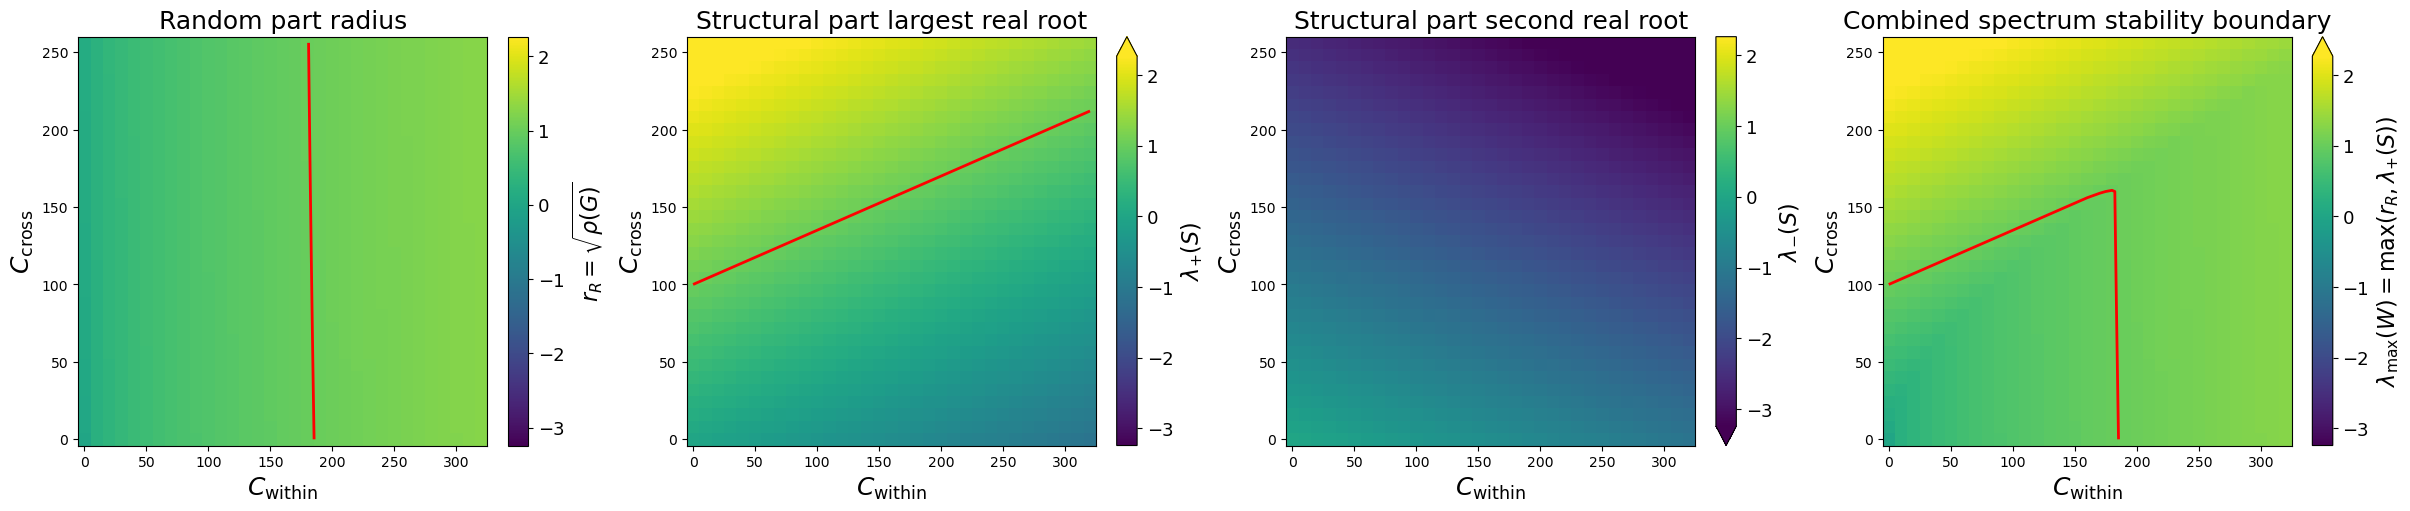

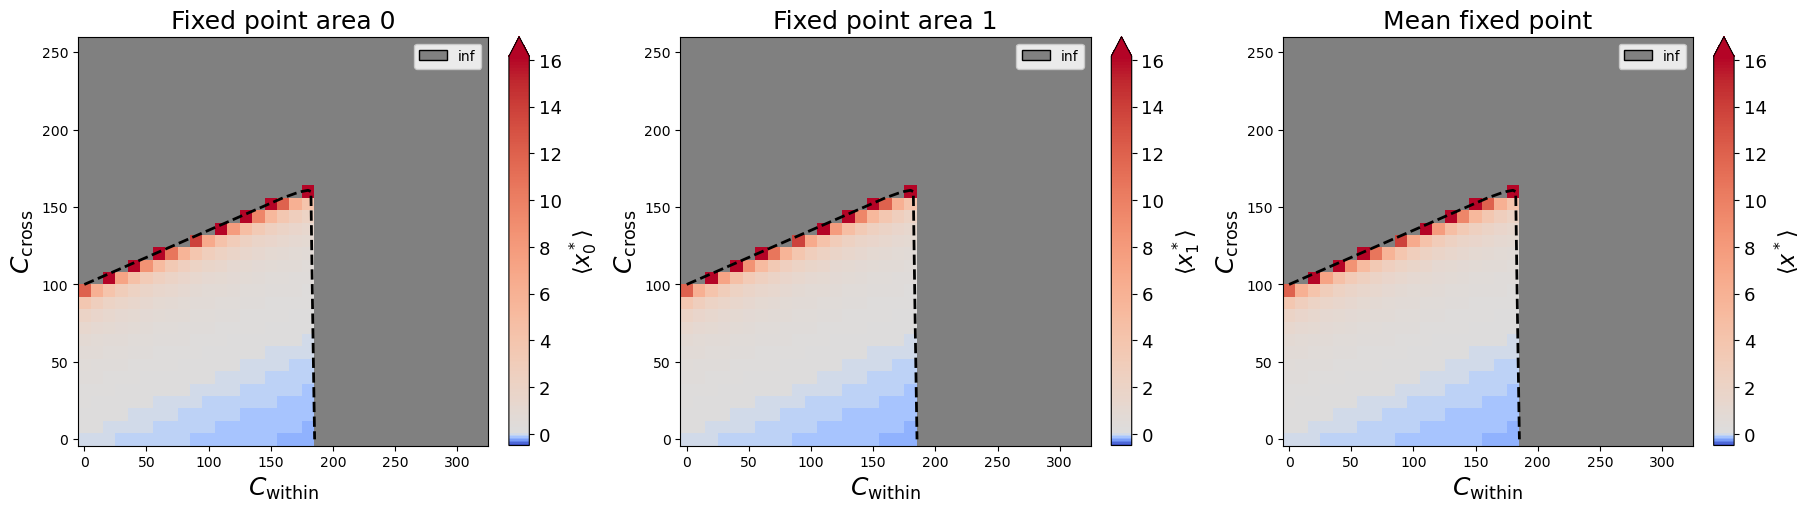

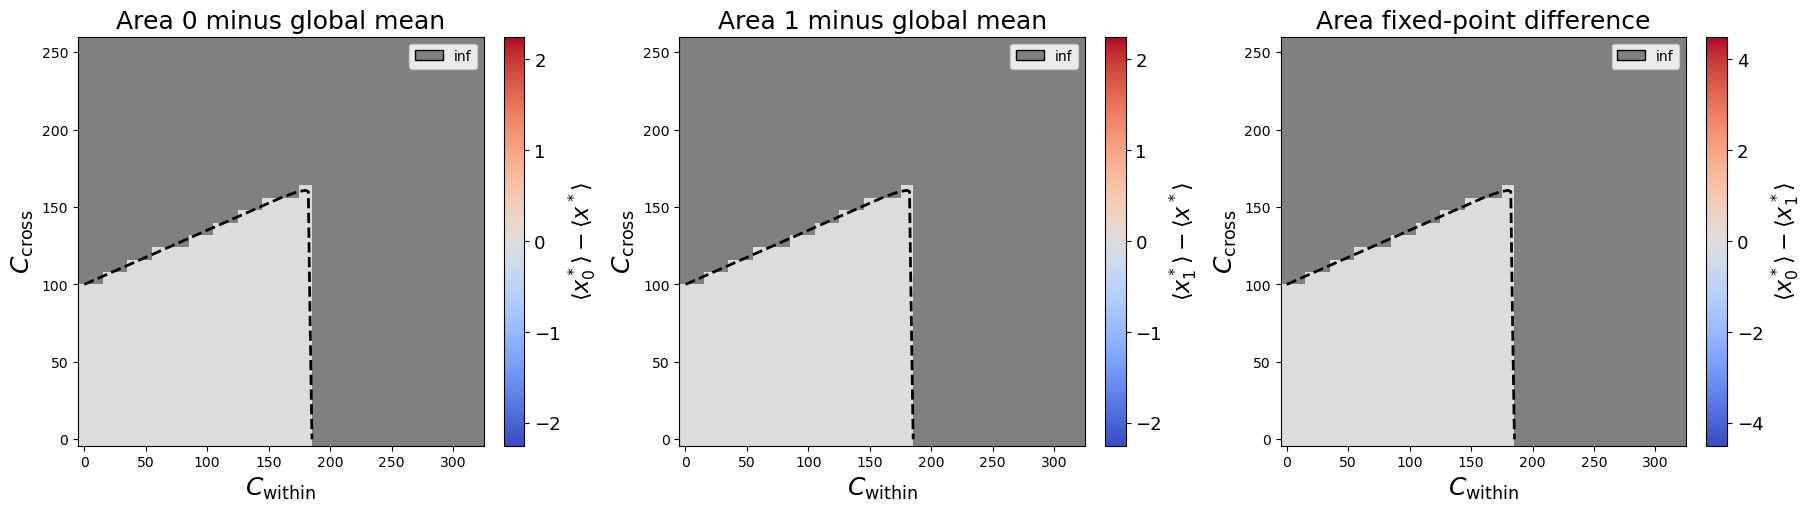

In [12]:
# ============================================================
# Example: exactly in your old scan style
# ============================================================

if __name__ == "__main__":
    from itertools import product

    area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)

    # s_cross_fixed = np.zeros((2, 2))
    # s_cross_fixed[0, 1] = 0.025
    # s_cross_fixed[1, 0] = 0.025

    J_cross_fixed = np.zeros((2, 2))
    J_cross_fixed[0, 1] = 0.01
    J_cross_fixed[1, 0] = 0.01

    base_p = MultiAreaParams(
        areas=(area0, area1),
        #s_cross=s_cross_fixed,
        s_cross=np.zeros((2, 2)),
        J_cross=J_cross_fixed,
        #J_cross=np.zeros((2, 2)),
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # keep the same generator style as your original code
    scan_points = (
        {
            "areas[0].s": s0,
            "areas[1].s": s0,
            "s_cross[1,0]": s,
            "s_cross[0,1]": s,
            # "J_cross[1,0]": J1,
            # "J_cross[0,1]": J1,
        }
        for s, s0 in product(
            np.linspace(0.0, 0.16, 33),
            np.linspace(0.0, 0.16, 33)
        )
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_s_within_s_cross.jsonl",
        solve_fixed_point=False,   # kept for compatibility
        flush_every=1,
    )

    # plot the four panels (R radius, S lambda_+, S lambda_-, combined W stability)
    fig, axes = plot_theory_triptych(
        records=records,
        #x_key="s_cross[1,0]",
        x_key="C_within[0]",
        y_key="C_cross[1,0]",
        #xlabel=r"$J_{\rm within}$",
        xlabel=r"$C_{\rm within}$",
        #xlabel=r"$J^{0\to1}_{\rm cross}$",
        ylabel=r"$C_{\rm cross}$",
        figsize=(24, 5),
    )
    plt.savefig("theory_scan_s_within_s_cross_spectra.png", dpi=300, bbox_inches="tight")
    plt.show()


    #Fixed-point theory plots are available from the same records:
    fig, axes = plot_fixed_point_theory_panels(
        records=records,
        x_key="C_within[0]",
        y_key="C_cross[1,0]",
        xlabel=r"$C_{\rm within}$",
        ylabel=r"$C_{\rm cross}$",
    )
    plt.savefig("theory_scan_s_within_s_cross_fixed_point.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    fig, axes = plot_fixed_point_difference_panels(
        records=records,
        x_key="C_within[0]",
        y_key="C_cross[1,0]",
        xlabel=r"$C_{\rm within}$",
        ylabel=r"$C_{\rm cross}$",
    )
    plt.show()

    #You can also plot any one metric generically:
    # plt.figure(figsize=(6, 5))
    # plot_metric_heatmap(
    #     records,
    #     x_key="J_cross[0,1]",
    #     y_key="J_cross[1,0]",
    #     z_key="W_lambda_max",
    #     title="Combined spectrum stability boundary",
    #     xlabel=r"$J^{0\to1}_{\rm cross}$",
    #     ylabel=r"$J^{1\to0}_{\rm cross}$",
    #     cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
    #     contour_level=1.0,
    # )
    # plt.show()


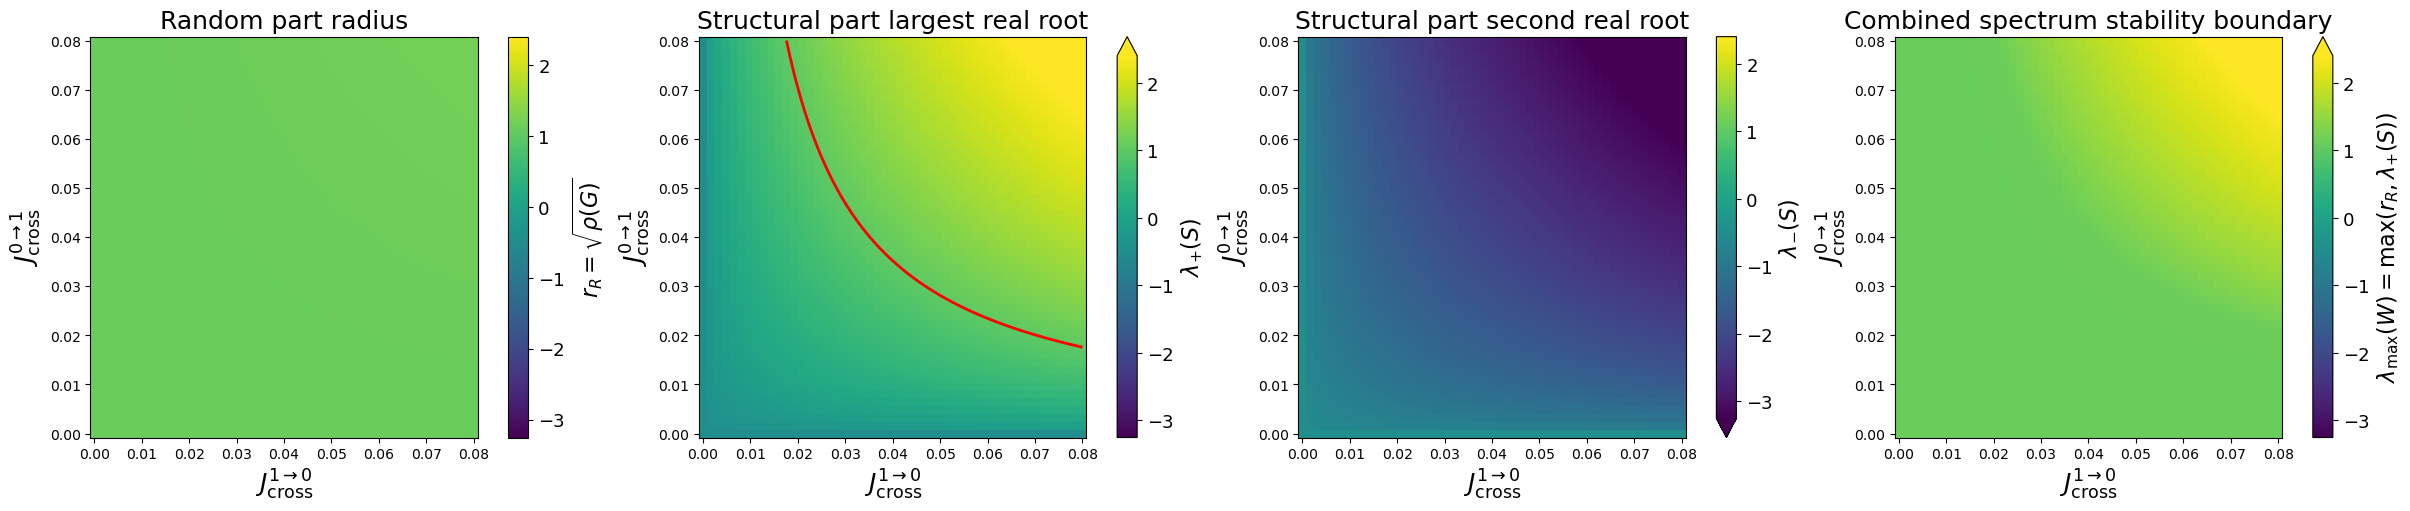

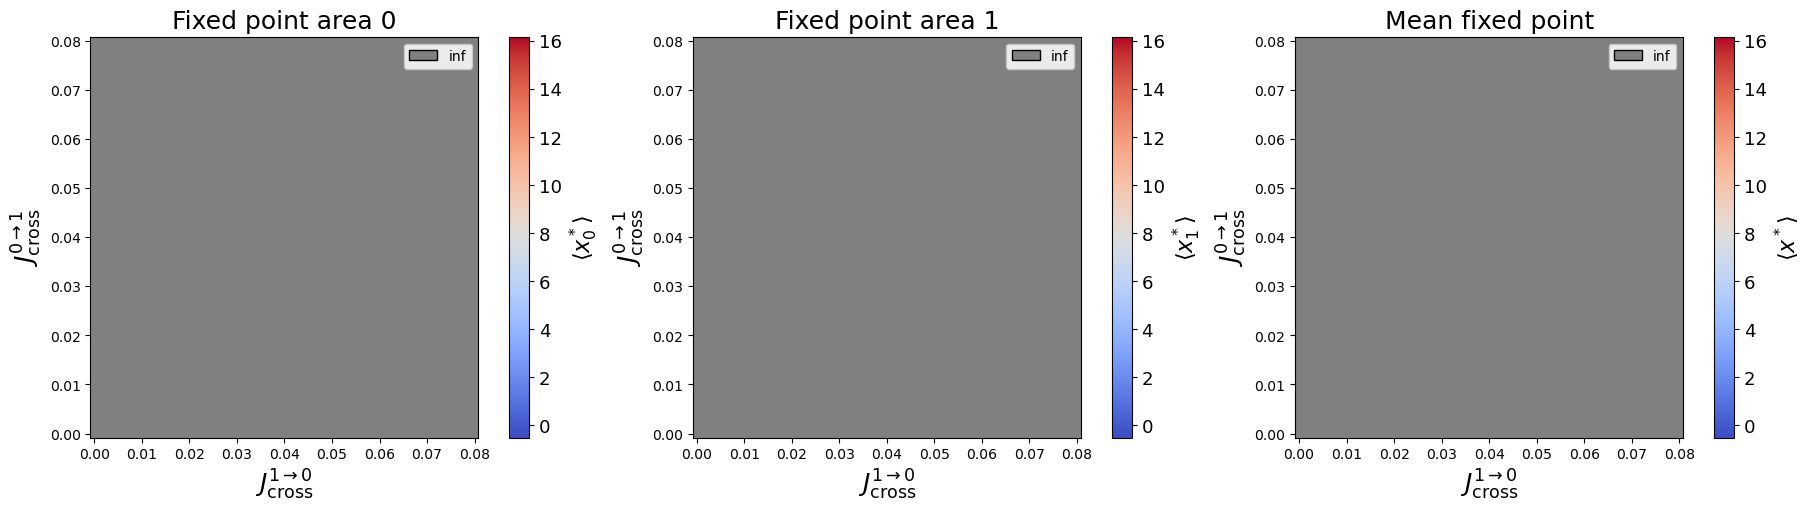

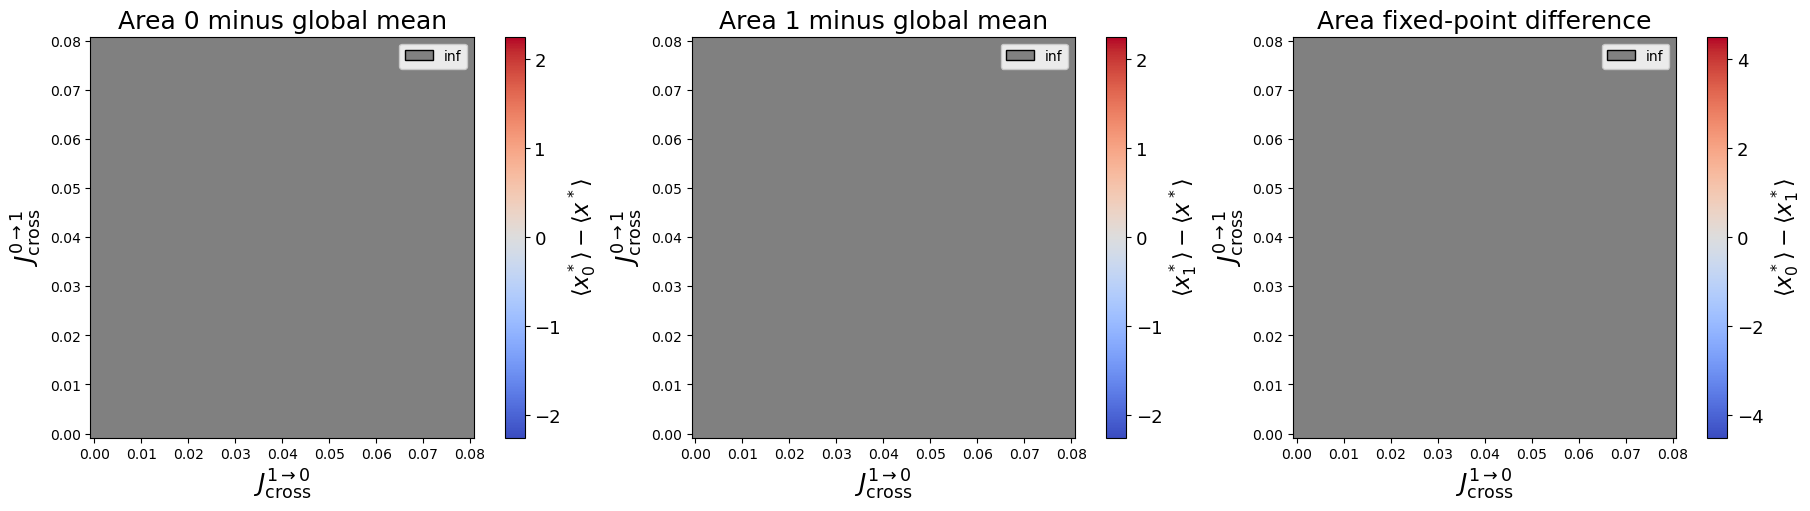

In [14]:
# ============================================================
# Example: exactly in your old scan style
# ============================================================

if __name__ == "__main__":
    from itertools import product

    area0 = AreaParams(N=100000, s=0.001, f_exc=0.8, J_exc=0.050, g_inh=4.5)
    area1 = AreaParams(N=100000, s=0.001, f_exc=0.8, J_exc=0.050, g_inh=4.5)

    s_cross_fixed = np.zeros((2, 2))
    s_cross_fixed[0, 1] = 0.0005
    s_cross_fixed[1, 0] = 0.0005

    # J_cross_fixed = np.zeros((2, 2))
    # J_cross_fixed[0, 1] = 0.01
    # J_cross_fixed[1, 0] = 0.01

    base_p = MultiAreaParams(
        areas=(area0, area1),
        s_cross=s_cross_fixed,
        #s_cross=np.zeros((2, 2)),
        #J_cross=J_cross_fixed,
        J_cross=np.zeros((2, 2)),
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # keep the same generator style as your original code
    scan_points = (
        {
            # "areas[0].s": s0,
            # "areas[1].s": s0,
            # "s_cross[1,0]": s,
            # "s_cross[0,1]": s,
            "J_cross[1,0]": J0,
            "J_cross[0,1]": J1,
        }
        for J0, J1 in product(
            np.linspace(0.0, 0.08, 51),
            np.linspace(0.0, 0.08, 51)
        )
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_J_cross_asymmetry.jsonl",
        solve_fixed_point=False,   # kept for compatibility
        flush_every=1,
    )

    # plot the four panels (R radius, S lambda_+, S lambda_-, combined W stability)
    fig, axes = plot_theory_triptych(
        records=records,
        #x_key="s_cross[1,0]",
        x_key="J_cross[1,0]",
        y_key="J_cross[0,1]",
        xlabel=r"$J^{1\to 0}_{\rm cross}$",
        ylabel=r"$J^{0\to 1}_{\rm cross}$",
        #ylabel=r"$s_{\rm cross}$",
        figsize=(24, 5),
    )
    plt.savefig("theory_scan_J_cross_asymmetry_spectra.png", dpi=300, bbox_inches="tight")
    plt.show()


    #Fixed-point theory plots are available from the same records:
    fig, axes = plot_fixed_point_theory_panels(
        records=records,
        x_key="J_cross[1,0]",
        y_key="J_cross[0,1]",
        xlabel=r"$J^{1\to 0}_{\rm cross}$",
        ylabel=r"$J^{0\to 1}_{\rm cross}$",
    )
    plt.savefig("theory_scan_J_cross_asymmetry_fixed_point.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    fig, axes = plot_fixed_point_difference_panels(
        records=records,
        x_key="J_cross[1,0]",
        y_key="J_cross[0,1]",
        xlabel=r"$J^{1\to 0}_{\rm cross}$",
        ylabel=r"$J^{0\to 1}_{\rm cross}$",
    )
    plt.savefig("theory_scan_J_cross_asymmetry_fixed_point_difference.png", dpi=300, bbox_inches="tight")
    plt.show()

    #You can also plot any one metric generically:
    # plt.figure(figsize=(6, 5))
    # plot_metric_heatmap(
    #     records,
    #     x_key="J_cross[0,1]",
    #     y_key="J_cross[1,0]",
    #     z_key="W_lambda_max",
    #     title="Combined spectrum stability boundary",
    #     xlabel=r"$J^{0\to1}_{\rm cross}$",
    #     ylabel=r"$J^{1\to0}_{\rm cross}$",
    #     cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
    #     contour_level=1.0,
    # )
    # plt.show()


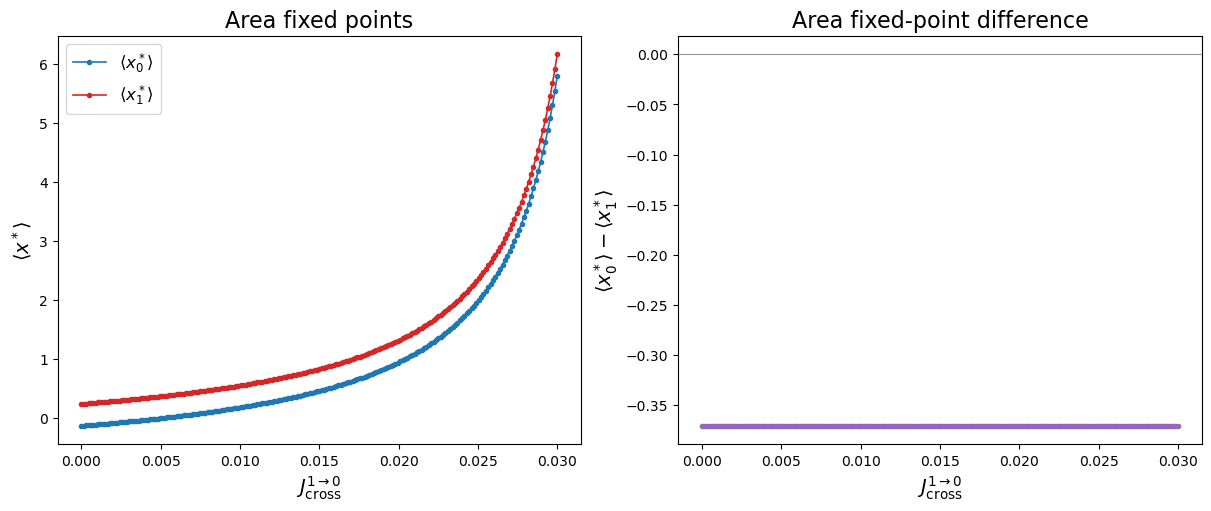

In [43]:
# ============================================================
# 1D scan: fixed point vs. J_cross[1,0] (asymmetric cross coupling)
# Vertical dashed lines at W_lambda_max = 1 crossings -- 1D analogue
# of the boundary contour drawn by overlay_stability_boundary.
# ============================================================

if __name__ == "__main__":
    area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)

    s_cross_fixed = np.zeros((2, 2))
    s_cross_fixed[0, 1] = 0.025
    s_cross_fixed[1, 0] = 0.025

    J_cross_fixed = np.zeros((2, 2))
    J_cross_fixed[0, 1] = 0.03375  # held fixed; J_cross[1,0] is scanned

    base_p = MultiAreaParams(
        areas=(area0, area1),
        s_cross=s_cross_fixed,
        J_cross=J_cross_fixed,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    scan_points = (
        {"J_cross[1,0]": Jc}
        for Jc in np.linspace(0.0, 0.03, 201)
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_J_cross10_1d.jsonl",
        flush_every=1,
    )

    fig, axes = plot_fixed_point_1d_scan(
        records,
        x_key="J_cross[1,0]",
        xlabel=r"$J^{1\to 0}_{\rm cross}$",
    )
    plt.savefig(
        "theory_scan_J_cross_asymmetric_1d_fixed_point.png",
        dpi=300, bbox_inches="tight",
    )
    plt.show()


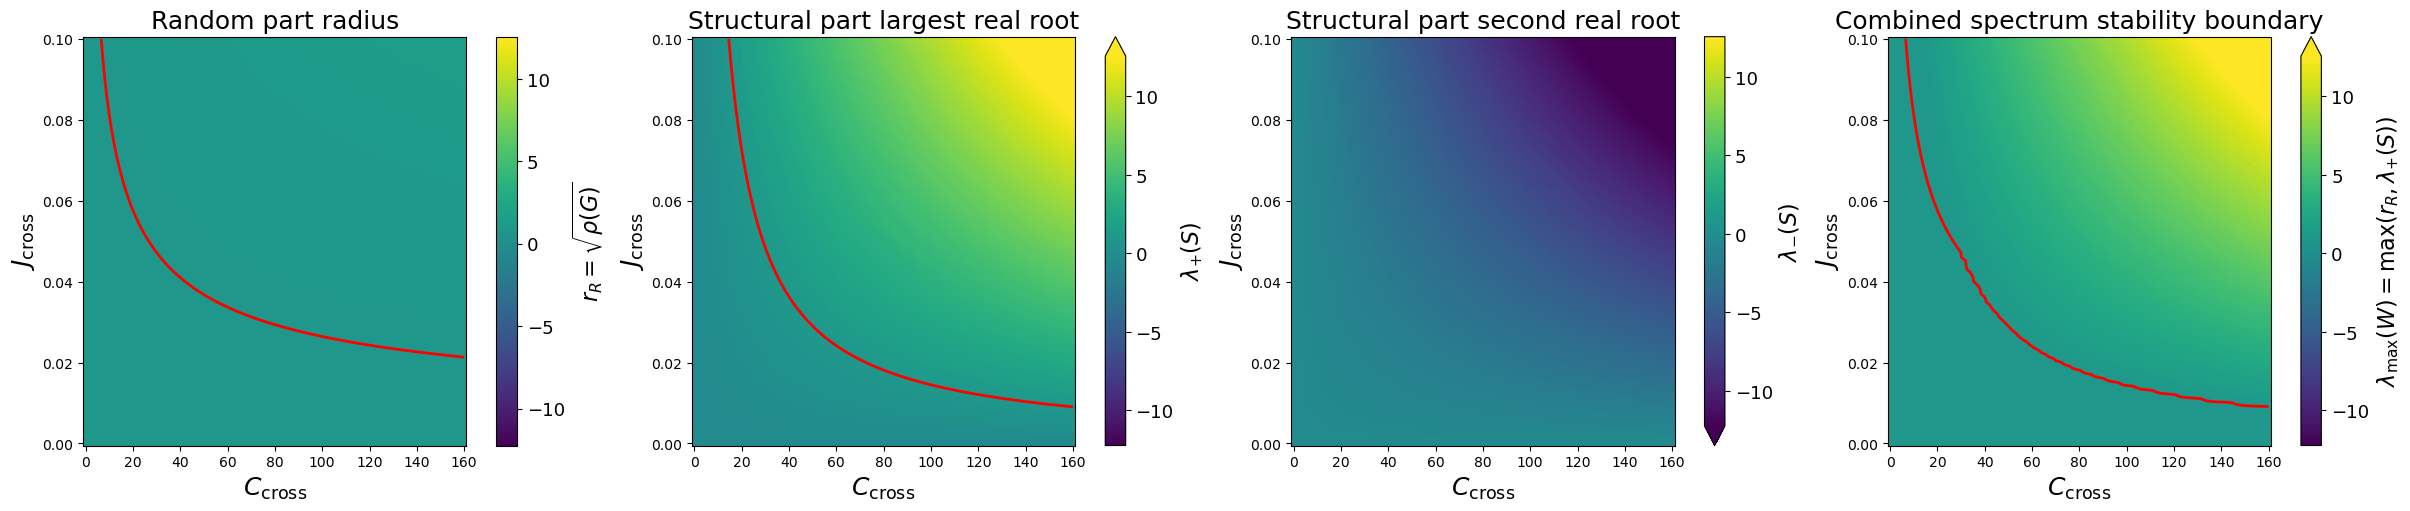

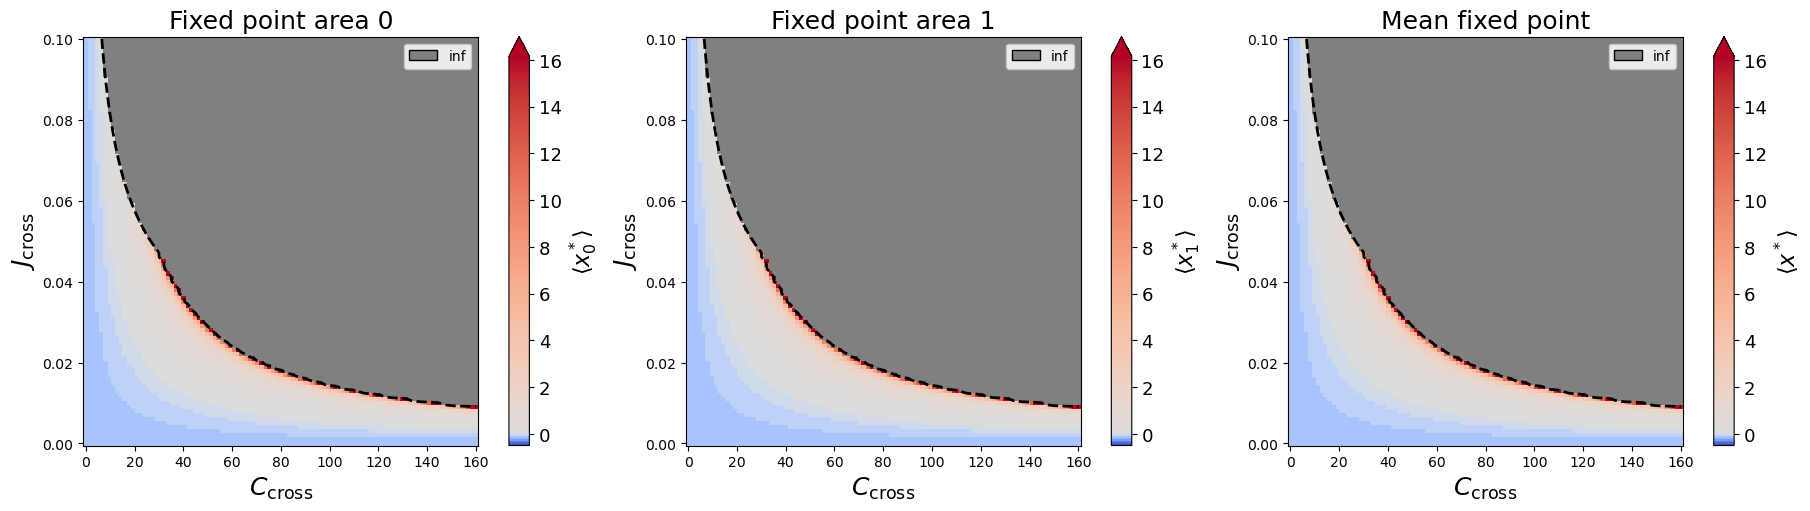

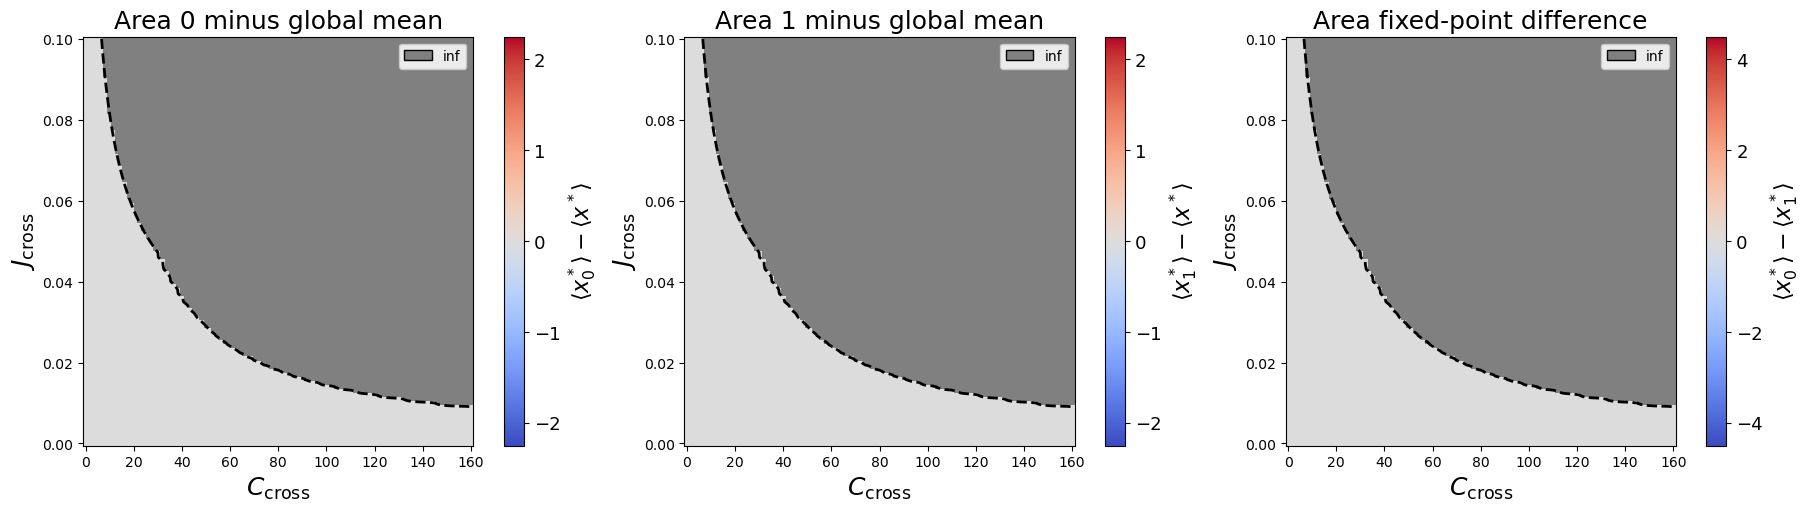

In [10]:
# ============================================================
# Example: exactly in your old scan style
# ============================================================

if __name__ == "__main__":
    from itertools import product

    area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.045, g_inh=4.5)
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.045, g_inh=4.5)

    # s_cross_fixed = np.zeros((2, 2))
    # s_cross_fixed[0, 1] = 0.025
    # s_cross_fixed[1, 0] = 0.025

    # J_cross_fixed = np.zeros((2, 2))
    # J_cross_fixed[0, 1] = 0.01
    # J_cross_fixed[1, 0] = 0.01

    base_p = MultiAreaParams(
        areas=(area0, area1),
        #s_cross=s_cross_fixed,
        s_cross=np.zeros((2, 2)),
        #J_cross=J_cross_fixed,
        J_cross=np.zeros((2, 2)),
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # keep the same generator style as your original code
    scan_points = (
        {
            "s_cross[1,0]": s,
            "s_cross[0,1]": s,
            "J_cross[1,0]": J,
            "J_cross[0,1]": J,
        }
        for s, J in product(
            np.linspace(0.0, 0.1, 101),
            np.linspace(0.0, 0.1, 101)
        )
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_s_cross_J_cross.jsonl",
        solve_fixed_point=False,   # kept for compatibility
        flush_every=1,
    )

    # plot the four panels (R radius, S lambda_+, S lambda_-, combined W stability)
    fig, axes = plot_theory_triptych(
        records=records,
        x_key="C_cross[1,0]",
        y_key="J_cross[0,1]",
        xlabel=r"$C_{\rm cross}$",
        ylabel=r"$J_{\rm cross}$",
        #ylabel=r"$s_{\rm cross}$",
        figsize=(24, 5),
    )
    plt.savefig("theory_scan_s_cross_J_cross_spectra.png", dpi=300, bbox_inches="tight")
    plt.show()


    #Fixed-point theory plots are available from the same records:
    fig, axes = plot_fixed_point_theory_panels(
        records=records,
        x_key="C_cross[1,0]",
        y_key="J_cross[0,1]",
        xlabel=r"$C_{\rm cross}$",
        ylabel=r"$J_{\rm cross}$",
    )
    plt.savefig("theory_scan_s_cross_J_cross_fixed_point.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    fig, axes = plot_fixed_point_difference_panels(
        records=records,
        x_key="C_cross[1,0]",
        y_key="J_cross[0,1]",
        xlabel=r"$C_{\rm cross}$",
        ylabel=r"$J_{\rm cross}$",
    )
    plt.show()

    #You can also plot any one metric generically:
    # plt.figure(figsize=(6, 5))
    # plot_metric_heatmap(
    #     records,
    #     x_key="J_cross[0,1]",
    #     y_key="J_cross[1,0]",
    #     z_key="W_lambda_max",
    #     title="Combined spectrum stability boundary",
    #     xlabel=r"$J^{0\to1}_{\rm cross}$",
    #     ylabel=r"$J^{1\to0}_{\rm cross}$",
    #     cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
    #     contour_level=1.0,
    # )
    # plt.show()


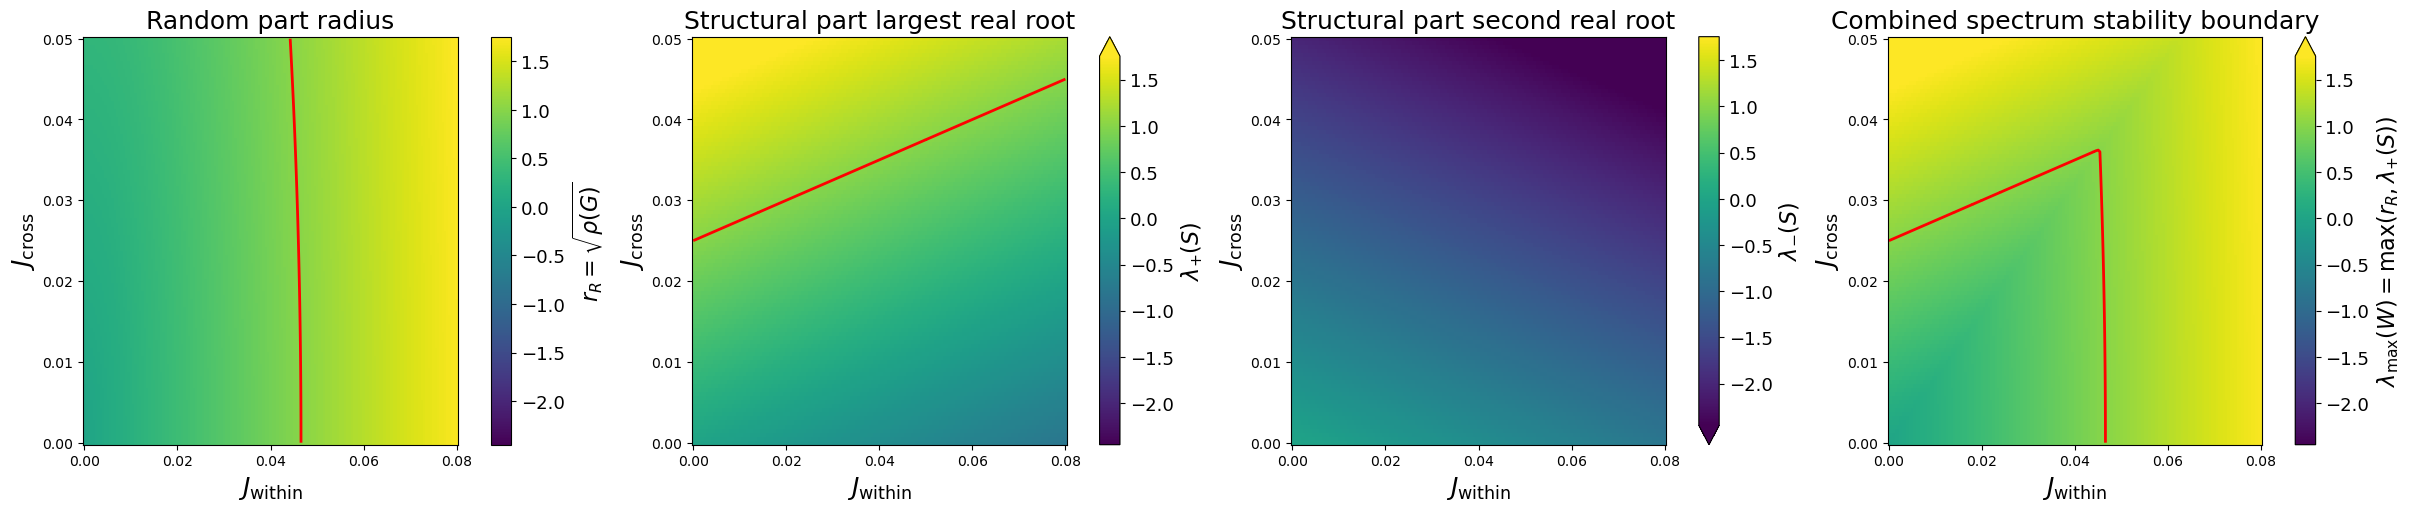

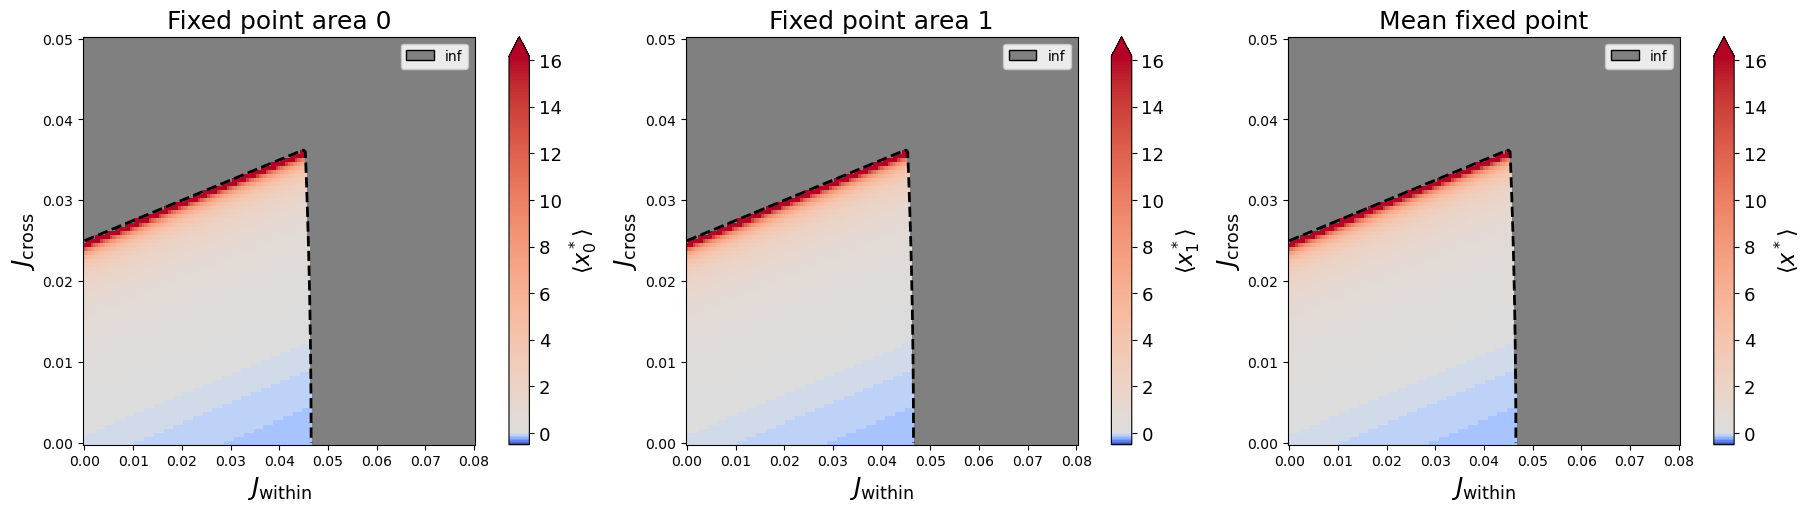

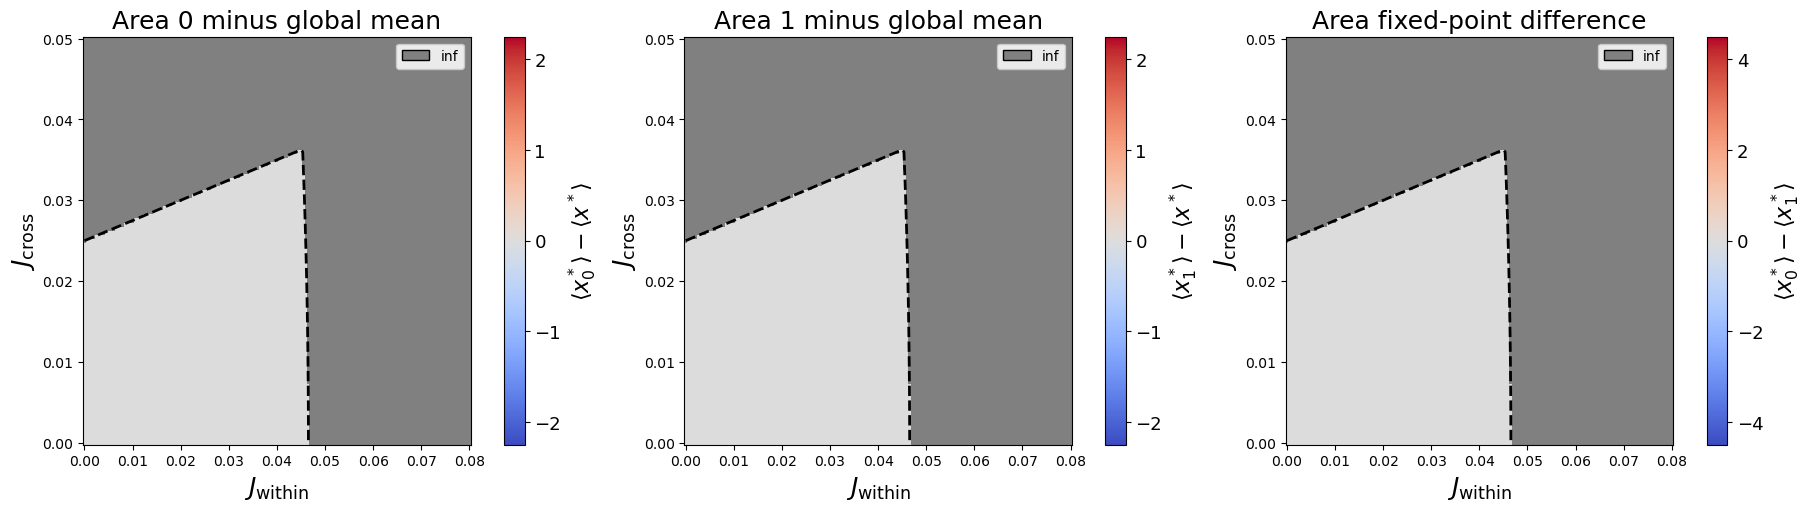

In [16]:
# ============================================================
# Example: exactly in your old scan style
# ============================================================

if __name__ == "__main__":
    from itertools import product

    area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)

    s_cross_fixed = np.zeros((2, 2))
    s_cross_fixed[0, 1] = 0.025
    s_cross_fixed[1, 0] = 0.025

    # J_cross_fixed = np.zeros((2, 2))
    # J_cross_fixed[0, 1] = 0.01
    # J_cross_fixed[1, 0] = 0.01

    base_p = MultiAreaParams(
        areas=(area0, area1),
        s_cross=s_cross_fixed,
        #s_cross=np.zeros((2, 2)),
        #J_cross=J_cross_fixed,
        J_cross=np.zeros((2, 2)),
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # keep the same generator style as your original code
    scan_points = (
        {
            "areas[0].J_exc": J0,
            "areas[1].J_exc": J0,
            # "s_cross[1,0]": s,
            # "s_cross[0,1]": s,
            "J_cross[1,0]": Jc,
            "J_cross[0,1]": Jc,
        }
        for J0, Jc in product(
            np.linspace(0.0, 0.08, 161),
            np.linspace(0.0, 0.05, 101)
        )
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_J_within_J_cross.jsonl",
        solve_fixed_point=False,   # kept for compatibility
        flush_every=1,
    )

    # plot the four panels (R radius, S lambda_+, S lambda_-, combined W stability)
    fig, axes = plot_theory_triptych(
        records=records,
        #x_key="s_cross[1,0]",
        x_key="areas[0].J_exc",
        y_key="J_cross[0,1]",
        xlabel=r"$J_{\rm within}$",
        ylabel=r"$J_{\rm cross}$",
        #ylabel=r"$s_{\rm cross}$",
        figsize=(24, 5),
    )
    plt.savefig("theory_scan_J_within_J_cross_fixed_spectra.png", dpi=300, bbox_inches="tight")
    plt.show()


    #Fixed-point theory plots are available from the same records:
    fig, axes = plot_fixed_point_theory_panels(
        records=records,
        x_key="areas[0].J_exc",
        y_key="J_cross[0,1]",
        xlabel=r"$J_{\rm within}$",
        ylabel=r"$J_{\rm cross}$",
    )
    plt.savefig("theory_scan_J_within_J_cross_fixed_point.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    fig, axes = plot_fixed_point_difference_panels(
        records=records,
        x_key="areas[0].J_exc",
        y_key="J_cross[0,1]",
        xlabel=r"$J_{\rm within}$",
        ylabel=r"$J_{\rm cross}$",
    )
    plt.show()

    #You can also plot any one metric generically:
    # plt.figure(figsize=(6, 5))
    # plot_metric_heatmap(
    #     records,
    #     x_key="J_cross[0,1]",
    #     y_key="J_cross[1,0]",
    #     z_key="W_lambda_max",
    #     title="Combined spectrum stability boundary",
    #     xlabel=r"$J^{0\to1}_{\rm cross}$",
    #     ylabel=r"$J^{1\to0}_{\rm cross}$",
    #     cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
    #     contour_level=1.0,
    # )
    # plt.show()


In [ ]:
# ============================================================
# 1D scan: fixed point vs. J_cross[1,0] (asymmetric cross coupling)
# Uses plot_fixed_point_1d_scan defined earlier (two-panel layout).
# Vertical black dashed lines mark W_lambda_max = 1 crossings -- the
# 1D analogue of the boundary contour drawn by overlay_stability_boundary.
# ============================================================

if __name__ == "__main__":
    area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)

    s_cross_fixed = np.zeros((2, 2))
    s_cross_fixed[0, 1] = 0.025
    s_cross_fixed[1, 0] = 0.025

    J_cross_fixed = np.zeros((2, 2))
    J_cross_fixed[0, 1] = 0.025  # held fixed; J_cross[1,0] is scanned

    base_p = MultiAreaParams(
        areas=(area0, area1),
        s_cross=s_cross_fixed,
        J_cross=J_cross_fixed,
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    scan_points = (
        {"J_cross[1,0]": Jc}
        for Jc in np.linspace(0.0, 0.06, 201)
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_J_cross10_1d.jsonl",
        flush_every=1,
    )

    fig, axes = plot_fixed_point_1d_scan(
        records,
        x_key="J_cross[1,0]",
        xlabel=r"$J^{1\to 0}_{\rm cross}$",
    )
    plt.savefig(
        "theory_scan_J_cross_asymmetric_1d_fixed_point.png",
        dpi=300, bbox_inches="tight",
    )
    plt.show()


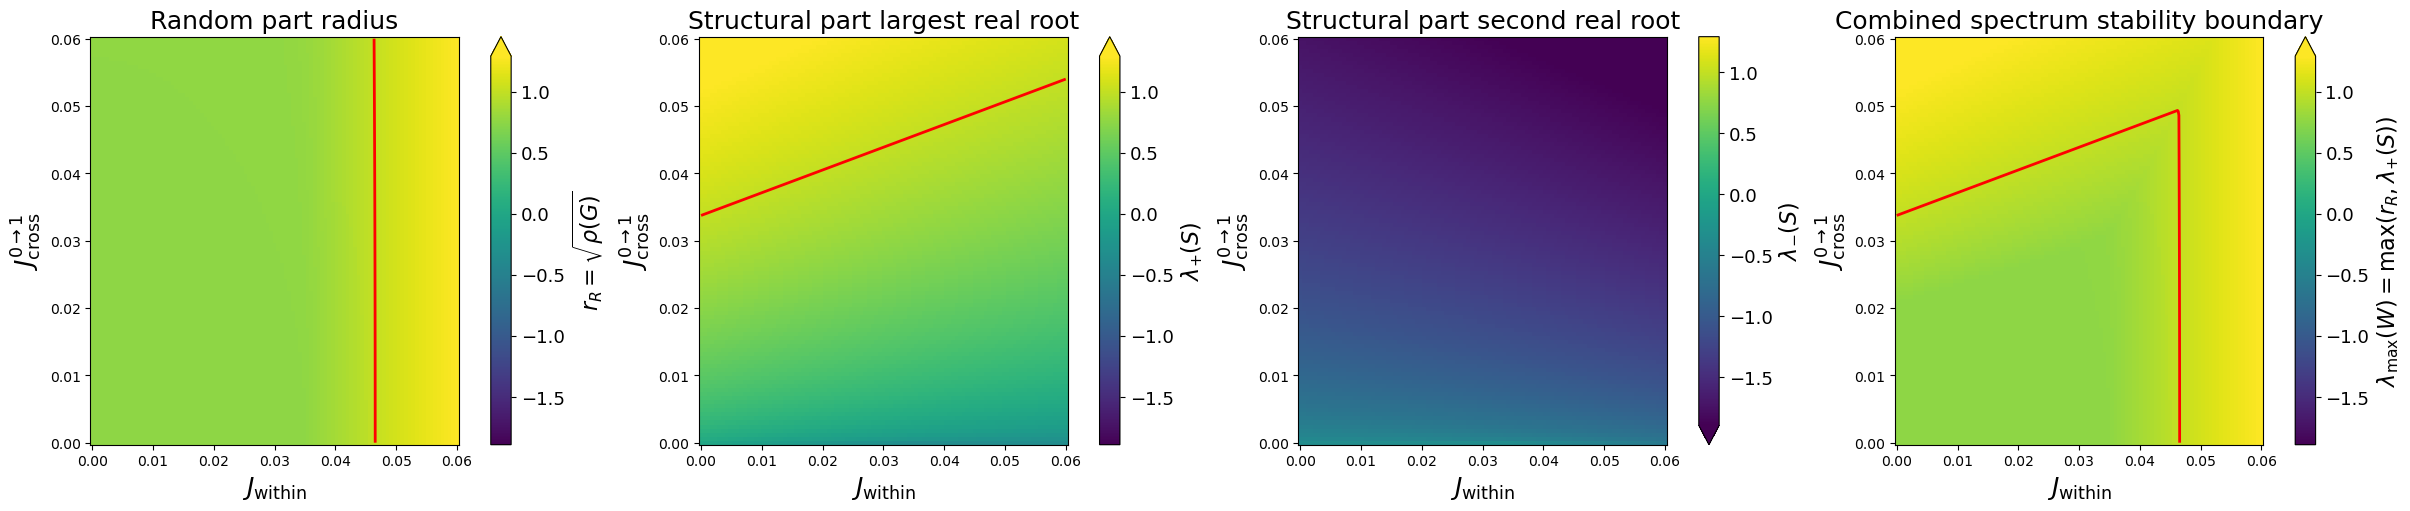

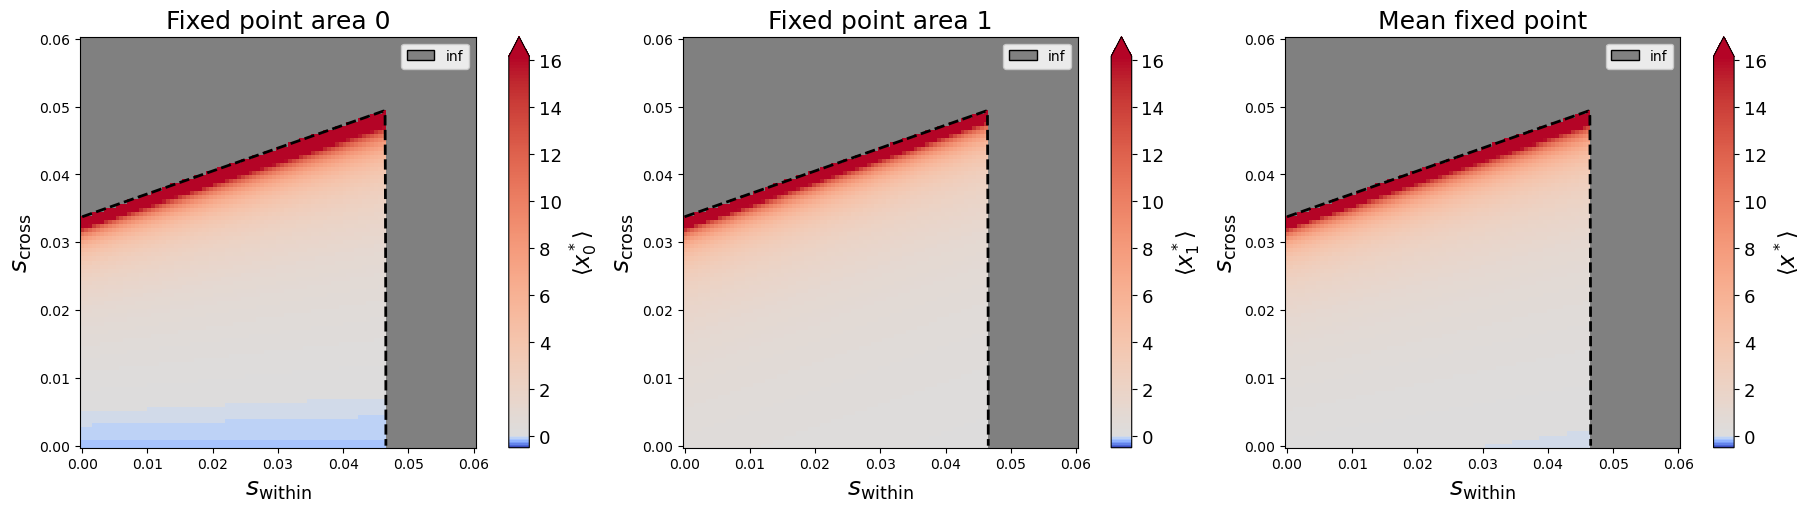

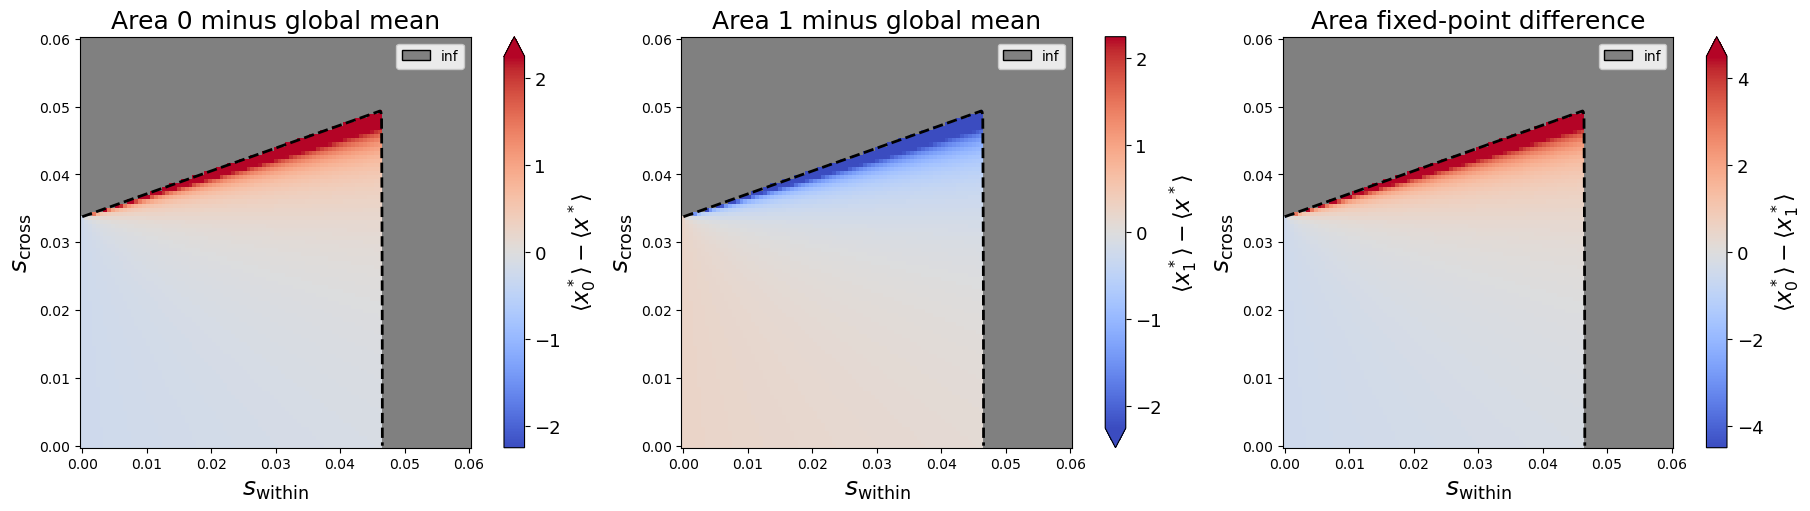

In [9]:
# ============================================================
# Example: exactly in your old scan style
# ============================================================

if __name__ == "__main__":
    from itertools import product

    area0 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)
    area1 = AreaParams(N=2000, s=0.05, f_exc=0.8, J_exc=0.035, g_inh=4.5)

    s_cross_fixed = np.zeros((2, 2))
    s_cross_fixed[0, 1] = 0.025
    s_cross_fixed[1, 0] = 0.025

    J_cross_fixed = np.zeros((2, 2))
    J_cross_fixed[0, 1] = 0.025
    # J_cross_fixed[1, 0] = 0.01

    base_p = MultiAreaParams(
        areas=(area0, area1),
        s_cross=s_cross_fixed,
        #s_cross=np.zeros((2, 2)),
        J_cross=J_cross_fixed,
        #J_cross=np.zeros((2, 2)),
        allow_autapses=False,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # keep the same generator style as your original code
    scan_points = (
        {
            # "areas[0].s": s0,
            # "areas[1].s": s0,
            "areas[1].J_exc": J0,
            # "s_cross[1,0]": s,
            # "s_cross[0,1]": s,
            "J_cross[1,0]": Jc,
            #"J_cross[0,1]": J1,
        }
        for J0, Jc in product(
            np.linspace(0.0, 0.06, 101),
            np.linspace(0.0, 0.06, 101)
        )
    )

    records = run_parameter_scan(
        base_p=base_p,
        scan_points=scan_points,
        output_file="theory_scan_cross_region_asymmetry.jsonl",
        solve_fixed_point=False,   # kept for compatibility
        flush_every=1,
    )

    # plot the four panels (R radius, S lambda_+, S lambda_-, combined W stability)
    fig, axes = plot_theory_triptych(
        records=records,
        #x_key="s_cross[1,0]",
        x_key="areas[1].J_exc",
        y_key="J_cross[1,0]",
        xlabel=r"$J_{\rm within}$",
        #xlabel=r"$s_{\rm within}$",
        ylabel=r"$J^{0\to1}_{\rm cross}$",
        #ylabel=r"$s_{\rm cross}$",
        figsize=(24, 5),
    )
    plt.show()


    #Fixed-point theory plots are available from the same records:
    fig, axes = plot_fixed_point_theory_panels(
        records=records,
        x_key="areas[1].J_exc",
        y_key="J_cross[1,0]",
        xlabel=r"$s_{\rm within}$",
        ylabel=r"$s_{\rm cross}$",
    )
    plt.show()
    
    fig, axes = plot_fixed_point_difference_panels(
        records=records,
        x_key="areas[1].J_exc",
        y_key="J_cross[1,0]",
        xlabel=r"$s_{\rm within}$",
        ylabel=r"$s_{\rm cross}$",
    )
    plt.show()

    #You can also plot any one metric generically:
    # plt.figure(figsize=(6, 5))
    # plot_metric_heatmap(
    #     records,
    #     x_key="J_cross[0,1]",
    #     y_key="J_cross[1,0]",
    #     z_key="W_lambda_max",
    #     title="Combined spectrum stability boundary",
    #     xlabel=r"$J^{0\to1}_{\rm cross}$",
    #     ylabel=r"$J^{1\to0}_{\rm cross}$",
    #     cbar_label=r"$\lambda_{\max}(W)=\max(r_R,\lambda_{+}(S))$",
    #     contour_level=1.0,
    # )
    # plt.show()
